# 11 — Complex Numbers; Quadratic Equations in the Complex Number System

**Chapter *Equations and Inequalities*, topic 3.**

### Where we are

Notebook 10 left one door closed on purpose. We proved (Theorem 5) that a quadratic
equation with $D<0$ has **no real solution**, and the picture agreed: the parabola floats
above the $x$-axis and never touches it. Then I wrote *not yet* and moved on.

Today we open that door.

We are also going to **repair** two theorems from notebook 10. Vieta's formulas (Thm 6) and
the factorisation theorem (Thm 7) were both stated with the condition "$D \ge 0$". That
condition was a scar left by a number system that was too small. By the end of today, both
theorems lose the condition and become simply *true*, always.

### The one sentence of this notebook

> A quadratic equation **always** has exactly two roots. If you cannot see them, you are
> looking in a place that is too small.

### The honest gap, stated now instead of at the end

At the end I will state the **Fundamental Theorem of Algebra** and I will **not** prove it.
That is the first time in this course I state something big without a proof. I will tell you
exactly why (its proof needs limits and continuity — mathematics from a much later chapter),
and I will tell you exactly which of today's results depend on it. Everything else in this
notebook is proved in full.

---

## 0. What we need from before (read this first)

This is a recall table. If a line here feels unfamiliar, go back to that notebook **before**
continuing.

| We will use | Where it was proved | What it says |
| --- | --- | --- |
| The number tower $\mathbb{N}\subset\mathbb{Z}\subset\mathbb{Q}\subset\mathbb{R}$ | nb 01 | each step was invented to solve an equation the old set could not solve |
| **Axioms of $\mathbb{R}$** | nb 01 | commutative, associative, distributive, identities, inverses — the rules we must *keep* |
| **Sign rules**, $t^{2}\ge 0$ | nb 01, Thm C | a real square is never negative — this is exactly the wall we hit |
| **Order axioms** ($a<b$ and $c>0$ $\Rightarrow$ $ac<bc$) | nb 01 | needed for a surprising theorem today (Thm 9) |
| $\sqrt{ab}=\sqrt a\,\sqrt b$ **only when $a,b\ge 0$** | nb 02 Thm 9, nb 08 Thm 4 | the hypothesis nobody reads — today it takes revenge |
| $\sqrt{t^{2}}=|t|$ | nb 02 Thm 8 | the bars, for the seventh time |
| **Perfect square** $(u+v)^{2}=u^{2}+2uv+v^{2}$, **difference of squares** $u^{2}-v^{2}=(u-v)(u+v)$ | nb 04 Thm 3 | our two workhorses |
| A polynomial of degree $n$ has **at most $n$ roots** | nb 04 Thm 8 | still true today, and today it becomes *exactly* $n$ |
| **Identity theorem** for polynomials | nb 04 Thm 9 | two polynomials are equal iff their coefficients match |
| **Factor theorem**: $r$ is a root $\iff$ $(x-r)$ divides $p$ | nb 05 / nb 06 | the bridge between roots and factors |
| **Rationalising** by multiplying by the conjugate | nb 08 §5 | today the same trick divides complex numbers |
| **Completing the square** and the **quadratic formula** | nb 10 Thm 3, Thm 4 | we redo the derivation, and this time we do not stop at $D<0$ |
| **The discriminant theorem** (Thm 5) | nb 10 | three cases: $D>0$, $D=0$, $D<0$ — today case 3 stops being a dead end |
| **Vieta** (Thm 6) and **factorisation** (Thm 7), both with "$D\ge0$" | nb 10 | the two theorems we repair today |

### Warm-up questions (answer out loud, before reading on)

1. Why is $\sqrt{25}=5$ and not $\pm 5$? Where does the $\pm$ in the quadratic formula
   really come from?
2. Notebook 10 said $x^{2}+1=0$ has no real solution. Give the **one-line reason**, naming
   the theorem you use.
3. $\sqrt{4}\cdot\sqrt{9}=\sqrt{36}$. Which theorem allows this, and what exactly does that
   theorem *require* about the two numbers?
4. A quadratic has roots $3$ and $5$. Without expanding, write down its sum and product of
   roots, and one equation that has exactly those roots.

---

## 1. Intuition first

### 1.1 The fourth time we needed a bigger number system

This has happened three times already in this course. Every time, the story was identical:
somebody wrote an equation, the equation had **no solution**, and instead of giving up,
mathematics **grew a new set of numbers** in which it does have a solution.

| Equation | Has no solution in | So people invented | New set |
| --- | --- | --- | --- |
| $x+3=1$ | $\mathbb{N}$ (counting numbers) | negative numbers | $\mathbb{Z}$ |
| $2x=1$ | $\mathbb{Z}$ (whole numbers) | fractions | $\mathbb{Q}$ |
| $x^{2}=2$ | $\mathbb{Q}$ (fractions) | irrational numbers | $\mathbb{R}$ |
| $x^{2}=-1$ | $\mathbb{R}$ (the number line) | **??? (today)** | $\mathbb{C}$ |

Look at the names people gave the new numbers each time:

* **negative** — from Latin *negare*, "to deny". A denied number.
* **irrational** — "without ratio", but in ordinary English it also means *not sensible*.
* **imaginary** — the name Descartes gave to today's numbers, and he meant it as an **insult**.

Every new kind of number was called fake by the people who met it first. Then it turned out
to be useful, then normal, then obvious. Today you think $-3$ is completely obvious. In 1545
it was not.

So the word *imaginary* is a historical accident. Nothing today is imaginary. We are going to
**build** the new numbers out of things you already have, with no magic and no lies.

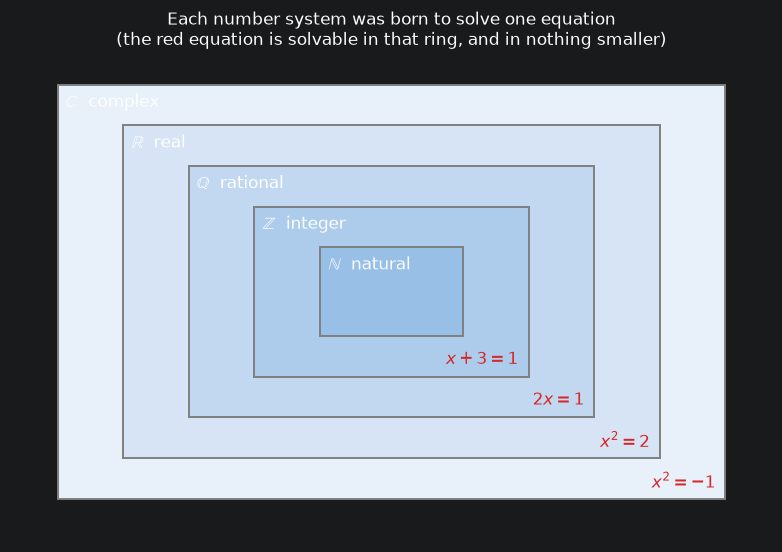

In [1]:
# --- Figure 1: the tower of number systems, and the equation that forced each step ---

import numpy as np                       # np = the fast-numbers tool (arrays and maths)
import matplotlib.pyplot as plt          # plt = matplotlib's drawing tool
from matplotlib.patches import Rectangle, Circle, FancyArrowPatch, Polygon

# One colour code for the WHOLE notebook, so every picture speaks the same language:
C_MAIN = "#1f77b4"   # blue   -> the complex number we are studying
C_ALT  = "#ff7f0e"   # orange -> a second complex number, or a conjugate
C_BAD  = "#d62728"   # red    -> something forbidden, or "no real solution"
C_GOOD = "#2ca02c"   # green  -> the result, the thing we built
C_GREY = "#7f7f7f"   # grey   -> helper lines, axes, old material

fig, ax = plt.subplots(figsize=(8.6, 5.6))

# Each row: (name of the set, the equation it can solve but the ring inside cannot,
#            half-width of its box, fill colour)
levels = [
    (r"$\mathbb{C}$  complex",   r"$x^2=-1$",  5.6, "#e8f0fa"),
    (r"$\mathbb{R}$  real",      r"$x^2=2$",   4.5, "#d6e4f5"),
    (r"$\mathbb{Q}$  rational",  r"$2x=1$",    3.4, "#c2d8f0"),
    (r"$\mathbb{Z}$  integer",   r"$x+3=1$",   2.3, "#adcbeb"),
    (r"$\mathbb{N}$  natural",   "",           1.2, "#98bfe6"),
]

# Draw from the biggest box to the smallest, so the small ones end up on top.
for name, eq, half, colour in levels:
    # Rectangle((left, bottom), width, height) -> a box centred on the origin
    ax.add_patch(Rectangle((-half, -half * 0.62), 2 * half, 2 * half * 0.62,
                           facecolor=colour, edgecolor=C_GREY, linewidth=1.4))
    # the name of the set, written just inside the top-left corner of its own box
    ax.text(-half + 0.14, half * 0.62 - 0.30, name, fontsize=12, va="center")
    if eq:
        # the equation that can be solved in this ring but in nothing smaller
        ax.text(half - 0.16, -half * 0.62 + 0.28, eq, fontsize=12,
                ha="right", va="center", color=C_BAD)

ax.set_xlim(-6.4, 6.4)
ax.set_ylim(-4.2, 4.0)
ax.set_aspect("equal")          # a square must look square
ax.axis("off")                  # a diagram, not a graph: hide the axes
ax.set_title("Each number system was born to solve one equation\n"
             "(the red equation is solvable in that ring, and in nothing smaller)",
             fontsize=12)
plt.tight_layout()
plt.show()

### 1.2 The rule we must not break

Here is the trap beginners fall into. They say:

> "Let $i$ be a number whose square is $-1$."

and then they feel uncomfortable, because notebook 01 Theorem C **proved** that
$t^{2}\ge 0$ for every real $t$. So it looks as if we have just contradicted a theorem.

**We have not, and here is why.** Theorem C says: *for every **real** number $t$*, we have
$t^{2}\ge 0$. It says nothing at all about objects that are not real numbers. We will not
change $\mathbb{R}$ by one millimetre. We will build a **bigger set**, in which $\mathbb{R}$
sits unchanged as a part, and in which there is a **new** object whose square is $-1$.

Compare with an old step: when you learned fractions, the sentence "no integer solves $2x=1$"
stayed true forever. $\tfrac12$ did not break it — $\tfrac12$ is simply not an integer.

So the honest question is not *"does $i$ exist?"*. It is:

> **Can we build a set of objects, containing the real numbers, with $+$ and $\times$ that
> obey all the usual rules, and containing an object whose square is $-1$?**

The answer is yes, and the construction is almost embarrassingly simple.

### 1.3 The idea: a number with two coordinates

A real number is one number: a point on a **line**. Our new numbers will be **pairs** of real
numbers: a point on a **plane**.

$$z = (a,\,b), \qquad a,b \in \mathbb{R}.$$

Adding is the obvious thing — add the coordinates, exactly like adding two moves on a map:

$$(a,b)+(c,d) = (a+c,\ b+d).$$

The whole invention is in the **multiplication**. And multiplication is *not* "multiply the
coordinates". If we tried $(a,b)\cdot(c,d)=(ac,\,bd)$, we would get a broken system: then
$(1,0)\cdot(0,1)=(0,0)$, so two non-zero things would multiply to zero, and notebook 01
Theorem B (the zero-product property) would die — and with it every method of notebook 10.
We need a better rule.

### 1.4 Where the multiplication rule comes from: turning

Think about what multiplying by $-1$ does on the number line. It sends $3$ to $-3$, and $-3$
to $3$. It is a **half-turn**: a rotation by $180^\circ$ around the point $0$.

Now ask the key question of this whole notebook:

> Is there something I can do **twice** that gives a half-turn?

Of course: **turn by $90^\circ$**, twice.

So if a "number" $i$ means *turn by $90^\circ$*, then $i\cdot i$ means *turn by $90^\circ$,
then turn by $90^\circ$ again*, which is *turn by $180^\circ$*, which is *multiply by $-1$*.
That is exactly

$$i^{2}=-1 .$$

Nothing was assumed. $i$ is not a mysterious number that we *swear* has square $-1$; $i$ is
the quarter-turn, and the quarter-turn done twice **is** the half-turn. Look at Figure 2 and
the mystery disappears.

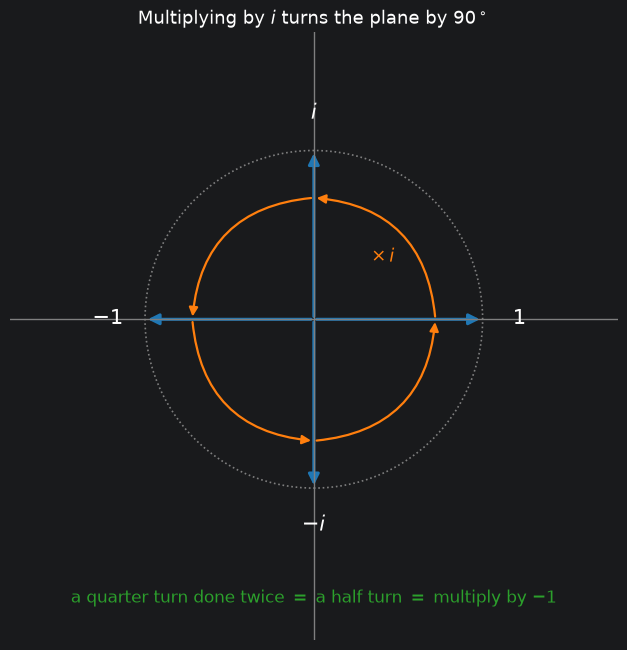

In [2]:
# --- Figure 2: multiplying by i means "turn a quarter of a circle" ---

fig, ax = plt.subplots(figsize=(6.6, 6.6))

# The four points 1, i, -1, -i written as (x, y) pairs on the plane
pts    = [(1, 0), (0, 1), (-1, 0), (0, -1)]
labels = [r"$1$", r"$i$", r"$-1$", r"$-i$"]

# the unit circle, drawn only as a light guide
ax.add_patch(Circle((0, 0), 1.0, fill=False, edgecolor=C_GREY,
                    linestyle=":", linewidth=1.2))

for (x, y), lab in zip(pts, labels):
    # an arrow from the origin to the point = "the number, seen as an arrow"
    ax.add_patch(FancyArrowPatch((0, 0), (x, y), arrowstyle="-|>",
                                 mutation_scale=16, linewidth=2.2, color=C_MAIN))
    ax.text(x * 1.22, y * 1.22, lab, fontsize=15, ha="center", va="center")

# four curved arrows, each one showing a single multiplication by i (a 90 degree turn)
for k in range(4):
    x0, y0 = pts[k]
    x1, y1 = pts[(k + 1) % 4]
    ax.add_patch(FancyArrowPatch((x0 * 0.72, y0 * 0.72), (x1 * 0.72, y1 * 0.72),
                                 connectionstyle="arc3,rad=0.42",   # bend the arrow
                                 arrowstyle="-|>", mutation_scale=13,
                                 linewidth=1.6, color=C_ALT))

ax.text(0.34, 0.34, r"$\times\, i$", fontsize=13, color=C_ALT)
ax.text(0, -1.68, r"a quarter turn done twice $=$ a half turn $=$ multiply by $-1$",
        fontsize=12, ha="center", color=C_GOOD)

ax.axhline(0, color=C_GREY, linewidth=1.0)   # the real axis
ax.axvline(0, color=C_GREY, linewidth=1.0)   # the imaginary axis
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.9, 1.7)
ax.set_aspect("equal")     # a circle must look like a circle
ax.axis("off")
ax.set_title(r"Multiplying by $i$ turns the plane by $90^\circ$", fontsize=13)
plt.tight_layout()
plt.show()

### 1.5 The multiplication rule, discovered instead of memorised

Now we can *derive* the rule instead of learning it by heart. Suppose the pair $(a,b)$ is a
short way of writing

$$a\cdot 1 + b\cdot i,$$

where $1$ is the point $(1,0)$ and $i$ is the point $(0,1)$. If we insist that the usual
rules of algebra (distributive law, and $x\cdot y = y\cdot x$) keep working, then we have no
freedom at all:

$$(a+bi)(c+di) = ac + adi + bci + bd\,i^{2} = ac + bd\,i^{2} + (ad+bc)\,i .$$

And now put $i^{2}=-1$:

$$(a+bi)(c+di) = (ac-bd) + (ad+bc)\,i .$$

That is the multiplication rule. It looks strange the first time, but nobody chose it —
**it is forced** by two decisions: keep the algebra rules, and let the quarter-turn square to
$-1$. In the formal definition below I will turn this around and *start* from

$$(a,b)\cdot(c,d) = (ac-bd,\ ad+bc),$$

so that nothing is assumed and $i^{2}=-1$ becomes a small **theorem** instead of a wish.

### 1.6 The picture: the complex plane

A complex number is a point of a plane, and also an arrow from the origin to that point. Two
words come with the picture:

* the **conjugate** $\bar z$: the mirror image of $z$ in the horizontal axis (flip the sign of
  the second coordinate). It is the twin of $z$.
* the **modulus** $|z|$: the **length** of the arrow. By Pythagoras (nb 03!),
  $|a+bi| = \sqrt{a^{2}+b^{2}}$.

Note what $|z|$ generalises: for a real number, $|a|=\sqrt{a^{2}}$ was the distance from $0$
on the *line* (nb 01, nb 02 Thm 8). Now it is the distance from $0$ in the *plane*. Same idea,
one dimension up. The bars did not change meaning; the world got wider.

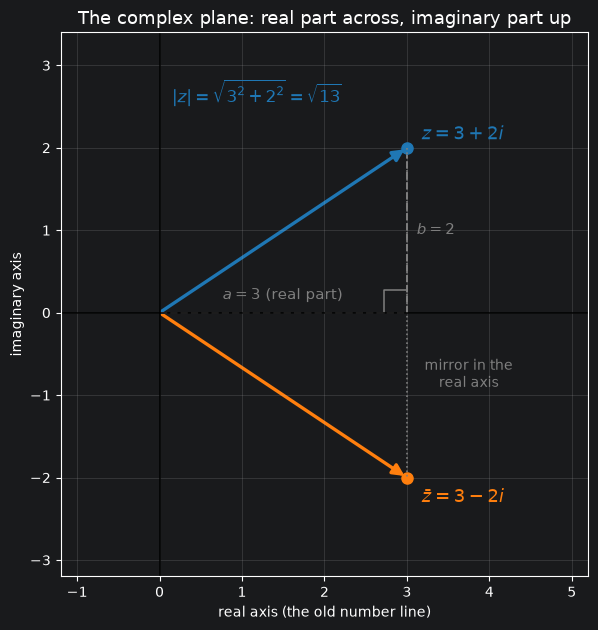

In [3]:
# --- Figure 3: the complex plane - a number is a point, an arrow, a mirror, a length ---

fig, ax = plt.subplots(figsize=(7.4, 6.4))

a, b = 3.0, 2.0          # our example number z = 3 + 2i

# the arrow for z
ax.add_patch(FancyArrowPatch((0, 0), (a, b), arrowstyle="-|>", mutation_scale=17,
                             linewidth=2.4, color=C_MAIN))
# the arrow for the conjugate: same first coordinate, opposite second coordinate
ax.add_patch(FancyArrowPatch((0, 0), (a, -b), arrowstyle="-|>", mutation_scale=17,
                             linewidth=2.4, color=C_ALT))

# the right triangle that gives the length by Pythagoras (notebook 03)
ax.plot([0, a], [0, 0], color=C_GREY, linewidth=1.4, linestyle="--")   # side a
ax.plot([a, a], [0, b], color=C_GREY, linewidth=1.4, linestyle="--")   # side b
ax.plot([a - 0.28, a - 0.28, a], [0, 0.28, 0.28], color=C_GREY, linewidth=1.1)  # right-angle mark

ax.plot([a], [b],  "o", color=C_MAIN, markersize=8)
ax.plot([a], [-b], "o", color=C_ALT,  markersize=8)

ax.text(a + 0.18, b + 0.10,  r"$z = 3 + 2i$",            fontsize=13, color=C_MAIN)
ax.text(a + 0.18, -b - 0.30, r"$\bar z = 3 - 2i$",        fontsize=13, color=C_ALT)
ax.text(0.15, 2.55, r"$|z|=\sqrt{3^2+2^2}=\sqrt{13}$",    fontsize=12, color=C_MAIN)
ax.text(1.5, 0.16, r"$a = 3$ (real part)", fontsize=11, color=C_GREY, ha="center")
ax.text(a + 0.12, b / 2, r"$b = 2$", fontsize=11, color=C_GREY, va="center")

# the mirror line: the conjugate is the reflection of z in the real axis
ax.plot([a, a], [b, -b], color=C_GREY, linestyle=":", linewidth=1.2)
ax.text(a + 0.75, -0.75, "mirror in the\nreal axis", fontsize=10, color=C_GREY,
        ha="center", va="center")

ax.axhline(0, color="black", linewidth=1.1)
ax.axvline(0, color="black", linewidth=1.1)
ax.set_xlim(-1.2, 5.2)
ax.set_ylim(-3.2, 3.4)
ax.set_aspect("equal")               # distances must be honest, so equal scaling
ax.set_xlabel("real axis (the old number line)")
ax.set_ylabel("imaginary axis")
ax.grid(alpha=0.25)
ax.set_title("The complex plane: real part across, imaginary part up", fontsize=13)
plt.tight_layout()
plt.show()

### 1.7 Addition is a move, multiplication is a turn-and-stretch

Two pictures worth keeping in your head for the rest of your life:

* **Adding** $z+w$: put the arrow $w$ at the tip of the arrow $z$. You get the diagonal of a
  parallelogram. Addition is *moving*.
* **Multiplying** $z\cdot w$: the lengths **multiply** and the turns **add**. Multiplication
  is *turning and stretching*.

The length half of that sentence I will prove today (Theorem 7: $|zw|=|z|\,|w|$). The angle
half needs trigonometry, which we have not met yet, so I will only show it in a picture and
mark it clearly as **not proved yet**. When we reach trigonometry it will get its proof.

Figure 4 shows the addition, Figure 5 shows the multiplication.

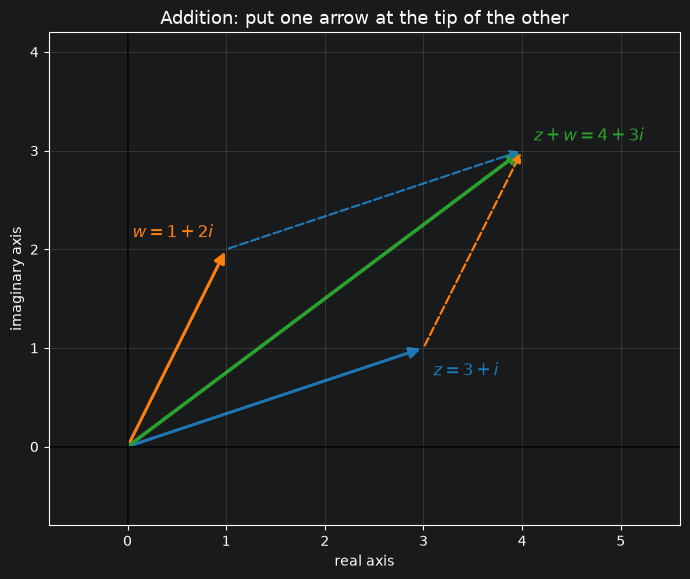

In [4]:
# --- Figure 4: adding complex numbers = adding arrows (the parallelogram) ---

fig, ax = plt.subplots(figsize=(7.0, 6.0))

z = (3, 1)                       # z = 3 + i
w = (1, 2)                       # w = 1 + 2i
s = (z[0] + w[0], z[1] + w[1])   # z + w = 4 + 3i, coordinate by coordinate

# the two original arrows, starting at the origin
ax.add_patch(FancyArrowPatch((0, 0), z, arrowstyle="-|>", mutation_scale=16,
                             linewidth=2.2, color=C_MAIN))
ax.add_patch(FancyArrowPatch((0, 0), w, arrowstyle="-|>", mutation_scale=16,
                             linewidth=2.2, color=C_ALT))
# the sum
ax.add_patch(FancyArrowPatch((0, 0), s, arrowstyle="-|>", mutation_scale=16,
                             linewidth=2.6, color=C_GOOD))
# the copy of w moved to the tip of z: this is what "adding a move" means
ax.add_patch(FancyArrowPatch(z, s, arrowstyle="-|>", mutation_scale=13,
                             linewidth=1.6, color=C_ALT, linestyle="--"))
# the copy of z moved to the tip of w, closing the parallelogram
ax.add_patch(FancyArrowPatch(w, s, arrowstyle="-|>", mutation_scale=13,
                             linewidth=1.6, color=C_MAIN, linestyle="--"))

ax.text(z[0] + 0.10, z[1] - 0.28, r"$z = 3+i$",        fontsize=12, color=C_MAIN)
ax.text(w[0] - 0.95, w[1] + 0.12, r"$w = 1+2i$",       fontsize=12, color=C_ALT)
ax.text(s[0] + 0.12, s[1] + 0.10, r"$z+w = 4+3i$",     fontsize=12, color=C_GOOD)

ax.axhline(0, color="black", linewidth=1.1)
ax.axvline(0, color="black", linewidth=1.1)
ax.set_xlim(-0.8, 5.6)
ax.set_ylim(-0.8, 4.2)
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.set_title("Addition: put one arrow at the tip of the other", fontsize=13)
plt.tight_layout()
plt.show()

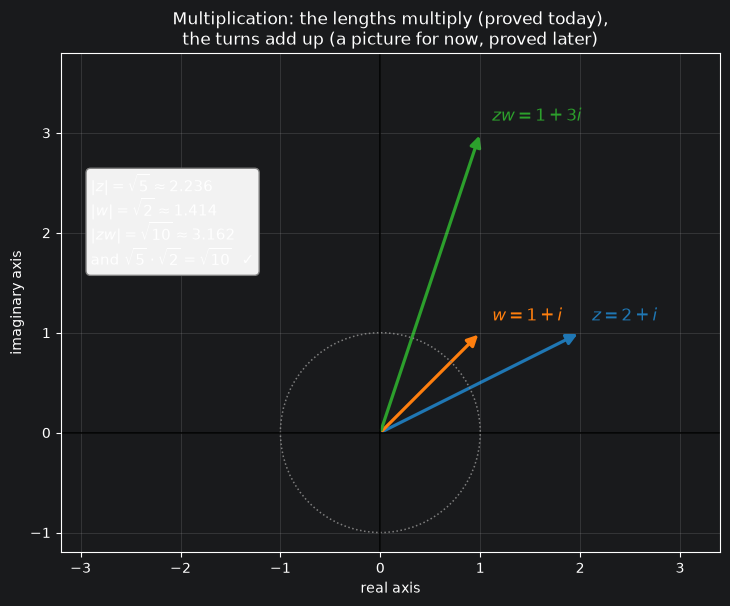

In [5]:
# --- Figure 5: multiplication = lengths multiply, turns add ---
# (the length part is Theorem 7 today; the angle part is a preview, proved in trigonometry)

fig, ax = plt.subplots(figsize=(7.4, 6.4))

# Python has complex numbers built in: 2+1j means 2 + i. The letter is j, not i,
# because engineers already use i for electric current - it is the same number.
z = 2 + 1j
w = 1 + 1j
p = z * w                       # Python multiplies with the rule we derived: (1) + (3)i

# a small helper: draw the complex number c as an arrow from 0, and label its tip
def arrow(c, colour, label, dx=0.12, dy=0.12, style="-"):
    ax.add_patch(FancyArrowPatch((0, 0), (c.real, c.imag), arrowstyle="-|>",
                                 mutation_scale=16, linewidth=2.3,
                                 color=colour, linestyle=style))
    ax.text(c.real + dx, c.imag + dy, label, fontsize=12, color=colour)

arrow(z, C_MAIN, r"$z = 2+i$")
arrow(w, C_ALT,  r"$w = 1+i$")
arrow(p, C_GOOD, r"$zw = 1+3i$")

# the unit circle, to make "length 1" visible
ax.add_patch(Circle((0, 0), 1.0, fill=False, edgecolor=C_GREY,
                    linestyle=":", linewidth=1.1))

# abs(c) is the length of the arrow: exactly our modulus |c|
txt = (r"$|z| = \sqrt{5} \approx %.3f$" % abs(z) + "\n" +
       r"$|w| = \sqrt{2} \approx %.3f$" % abs(w) + "\n" +
       r"$|zw| = \sqrt{10} \approx %.3f$" % abs(p) + "\n" +
       r"and $\sqrt{5} \cdot \sqrt{2} = \sqrt{10}$  " + u"✓")
ax.text(-2.9, 2.6, txt, fontsize=11, va="top",
        bbox=dict(boxstyle="round", facecolor="#f2f2f2", edgecolor=C_GREY))

ax.axhline(0, color="black", linewidth=1.1)
ax.axvline(0, color="black", linewidth=1.1)
ax.set_xlim(-3.2, 3.4)
ax.set_ylim(-1.2, 3.8)
ax.set_aspect("equal")
ax.grid(alpha=0.25)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.set_title("Multiplication: the lengths multiply (proved today),\n"
             "the turns add up (a picture for now, proved later)", fontsize=12)
plt.tight_layout()
plt.show()

### 1.8 What this buys us for equations

Back to notebook 10. The equation $x^{2}+1=0$ has $D=-4<0$, so no real solution: the parabola
floats above the axis. In the new system:

$$x^{2}=-1 \quad\Longrightarrow\quad x=i \ \text{ or }\ x=-i .$$

Two solutions, exactly as a degree-2 polynomial should have. And this is not luck. We will
prove that **every** quadratic — even one with complex coefficients — has exactly two roots
in $\mathbb{C}$ when we count a double root twice.

That is the pattern of the whole notebook: nothing new to *compute*, everything you learned
in notebook 10 still works, and the exceptions disappear.

### 1.9 The plan

1. Build $\mathbb{C}$ honestly from pairs of real numbers (§2).
2. Prove the arithmetic works, including division (§3, Thms 1–6).
3. Prove the size rules: $|zw|=|z||w|$ and the triangle inequality (Thm 7).
4. Prove $\mathbb{C}$ **cannot be ordered** — there is no "$<$" for complex numbers (Thm 9).
   This is why we will keep doing inequalities in $\mathbb{R}$ forever.
5. Redo the quadratic formula in $\mathbb{C}$ and repair notebook 10 (Thms 11–13).
6. Prove that every complex number has a square root (Thm 14), so *complex* coefficients are
   fine too.
7. State the Fundamental Theorem of Algebra without proof, honestly (Thm 15).

---

## 2. Formal definitions

Every symbol is defined the first time it appears. Read this section slowly; the rest of the
notebook only uses what is written here.

---

**Definition 1 (the set $\mathbb{C}$ and its two operations).**
$\mathbb{C}$ is the set of all **ordered pairs** of real numbers,

$$\mathbb{C} = \{\,(a,b)\ :\ a\in\mathbb{R},\ b\in\mathbb{R}\,\},$$

with the two operations

$$(a,b) + (c,d) := (a+c,\ b+d),$$
$$(a,b) \cdot (c,d) := (ac-bd,\ ad+bc).$$

The symbol $:=$ means "is defined to be". *Ordered* pair means the order matters:
$(1,2)\ne(2,1)$.

Notice: the right-hand sides use only **real** addition, subtraction and multiplication.
Nothing new is assumed to exist. If real numbers exist, these pairs exist.

---

**Definition 2 (equality).** $(a,b)=(c,d)$ means $a=c$ **and** $b=d$. Two complex numbers are
equal exactly when both coordinates match. (This will be used constantly: one complex equation
is really **two real equations**.)

---

**Definition 3 (the real numbers inside $\mathbb{C}$, and the number $i$).**
For a real number $a$ we write the pair $(a,0)$ simply as $a$. And we give one pair a name:

$$i := (0,1).$$

Theorem 2 will show that this renaming is safe: pairs of the form $(a,0)$ add and multiply
exactly like real numbers, so $\mathbb{R}$ really does sit inside $\mathbb{C}$ unchanged.

---

**Definition 4 (standard form).** By Theorem 3, every $z\in\mathbb{C}$ can be written in
exactly one way as

$$z = a + bi \qquad\text{with } a,b\in\mathbb{R}.$$

This is the **standard form** (or *rectangular form*) of $z$. We call

* $a =: \operatorname{Re}(z)$ the **real part** of $z$,
* $b =: \operatorname{Im}(z)$ the **imaginary part** of $z$.

**Warning that costs marks:** the imaginary part is the real number $b$, **not** $bi$. The
imaginary part of $3-2i$ is $-2$.

A number with $b=0$ is **real**. A number with $a=0$ and $b\ne0$ is called **pure
imaginary**. In $a+bi$, the letters $a$ and $b$ must be **real** numbers — otherwise it is
not standard form.

---

**Definition 5 (conjugate).** The **conjugate** of $z=a+bi$ is

$$\bar z := a - bi .$$

In the picture it is the mirror image of $z$ in the real axis (Figure 3).

---

**Definition 6 (modulus).** The **modulus** (or *absolute value*) of $z=a+bi$ is the real
number

$$|z| := \sqrt{a^{2}+b^{2}} \ \ (\ge 0).$$

It is the length of the arrow from $0$ to $z$ — Pythagoras, from notebook 03. For a real
number ($b=0$) this gives $|a|=\sqrt{a^{2}}$, the old absolute value from notebook 01. The
old meaning is a special case of the new one.

---

**Definition 7 (subtraction and division).** As always, the new operations are defined from
the old ones:

$$z - w := z + (-w), \qquad \frac{z}{w} := z\cdot w^{-1} \quad (w \ne 0),$$

where $-w$ is the additive inverse and $w^{-1}$ is the multiplicative inverse of $w$.
Theorem 1 and Theorem 6 prove that these two objects exist and are unique.

---

**Definition 8 (the square root of a negative real number).** For a real number $N>0$ we
define

$$\sqrt{-N} := i\sqrt{N},$$

where $\sqrt N$ is the ordinary principal square root of the positive number $N$ (nb 08).

Read this carefully: it is a **definition**, a decision about notation, not a theorem.
Theorem 10 will show that $-N$ has exactly **two** square roots, $i\sqrt N$ and $-i\sqrt N$,
and that neither is "bigger" than the other (Theorem 9 says complex numbers cannot be
compared). So we simply *choose* one and call it $\sqrt{-N}$. With real positive numbers we
could choose the positive root and the choice felt natural; here the choice is pure
convention.

---

**Definition 9 (root, multiplicity, and "solve" over $\mathbb{C}$).** For a polynomial $p$
with complex coefficients, $r\in\mathbb{C}$ is a **root** of $p$ if $p(r)=0$. As in notebook
05, $r$ has **multiplicity $m$** if $(x-r)^{m}$ divides $p$ but $(x-r)^{m+1}$ does not.

From now on, a problem must say **where** it wants the solutions. "Solve in $\mathbb{R}$" and
"solve in $\mathbb{C}$" are different questions with different answers: for $x^{2}+1=0$ the
first answer is $S=\varnothing$ and the second is $S=\{i,-i\}$. Neither is wrong. Always
state the set you are solving in.

---

## 3. Theorems, with full proofs

### 3.1 The arithmetic of $\mathbb{C}$

**Theorem 1 (the field axioms hold in $\mathbb{C}$).** For all $z,w,u \in \mathbb{C}$:

1. $z+w = w+z$ and $zw = wz$ (**commutative**);
2. $(z+w)+u = z+(w+u)$ and $(zw)u = z(wu)$ (**associative**);
3. $z(w+u) = zw + zu$ (**distributive**);
4. $(0,0)$ satisfies $z+(0,0)=z$, and $(1,0)$ satisfies $z\cdot(1,0)=z$ (**identities**);
5. every $z=(a,b)$ has the additive inverse $-z=(-a,-b)$, i.e. $z+(-z)=(0,0)$.

*(Multiplicative inverses come in Theorem 6, after we have the conjugate.)*

**Proof.** Everything is real-number algebra on the coordinates, so every step is allowed by
an axiom of $\mathbb{R}$ from notebook 01. Write $z=(a,b)$, $w=(c,d)$, $u=(e,f)$.

**(1) Addition is commutative.**
$$z+w=(a+c,\ b+d)=(c+a,\ d+b)=w+z,$$
using commutativity of $+$ in $\mathbb{R}$ in each coordinate.

**(1) Multiplication is commutative.**
$$zw = (ac-bd,\ ad+bc), \qquad wz = (ca-db,\ cb+da).$$
In $\mathbb{R}$, $ac=ca$ and $bd=db$, so the first coordinates agree. Also $cb+da = ad+bc$
(commutativity, then commutativity of $+$), so the second coordinates agree. By Definition 2,
$zw=wz$. $\;\square$ (for this part)

**(2) Addition is associative.** Both sides are $(a+c+e,\ b+d+f)$ by associativity of $+$ in
$\mathbb{R}$, coordinate by coordinate.

**(2) Multiplication is associative.** This is the only long computation in the notebook. Do
it once, carefully, and never again.

$$(zw)u = \big((ac-bd),\ (ad+bc)\big)\cdot (e,f).$$

By Definition 1 the first coordinate of this is
$$(ac-bd)e-(ad+bc)f = ace-bde-adf-bcf,$$
and the second coordinate is
$$(ac-bd)f+(ad+bc)e = acf-bdf+ade+bce.$$

Now the other bracketing:
$$z(wu) = (a,b)\cdot\big((ce-df),\ (cf+de)\big).$$
Its first coordinate is
$$a(ce-df)-b(cf+de) = ace-adf-bcf-bde,$$
and its second coordinate is
$$a(cf+de)+b(ce-df) = acf+ade+bce-bdf.$$

Compare: first coordinates are both $ace-bde-adf-bcf$; second coordinates are both
$acf-bdf+ade+bce$ (the same four terms in a different order). By Definition 2,
$(zw)u=z(wu)$.

**(3) Distributive law.**
$$z(w+u) = (a,b)\cdot(c+e,\ d+f) = \big(a(c+e)-b(d+f),\ a(d+f)+b(c+e)\big)$$
$$= \big((ac-bd)+(ae-bf),\ (ad+bc)+(af+be)\big)$$
$$= (ac-bd,\ ad+bc) + (ae-bf,\ af+be) = zw+zu .$$
Every step used only the distributive law in $\mathbb{R}$ and Definition 1.

**(4) Identities.** $z+(0,0)=(a+0,\ b+0)=(a,b)=z$. And
$$z\cdot(1,0) = (a\cdot 1-b\cdot 0,\ a\cdot 0+b\cdot 1) = (a,b)=z .$$

**(5) Additive inverse.** $(a,b)+(-a,-b) = (a-a,\ b-b) = (0,0)$. $\blacksquare$

**Why this theorem matters more than it looks.** It says: *you may do algebra in
$\mathbb{C}$ exactly as you did in $\mathbb{R}$.* Every identity we proved with letters —
$(u+v)^{2}=u^{2}+2uv+v^{2}$, $u^{2}-v^{2}=(u-v)(u+v)$, completing the square, the binomial
work of notebook 04 — was proved **using only these axioms**. So all of it is automatically
true in $\mathbb{C}$ too. We do not have to prove any of it again. That is the real payment
for the long computation above.

---

**Theorem 2 ($\mathbb{R}$ sits inside $\mathbb{C}$, and $i^{2}=-1$).**

(a) For all real $a,c$: $(a,0)+(c,0)=(a+c,0)$ and $(a,0)\cdot(c,0)=(ac,0)$.

(b) $i^{2} = -1$, that is, $(0,1)\cdot(0,1) = (-1,0)$.

**Proof.** (a) Addition: $(a,0)+(c,0)=(a+c,\ 0+0)=(a+c,0)$. Multiplication, by Definition 1:
$$(a,0)\cdot(c,0) = (ac-0\cdot 0,\ a\cdot 0+0\cdot c) = (ac,\ 0).$$
So the pairs with second coordinate $0$ add and multiply exactly like the real numbers
themselves. Writing $a$ instead of $(a,0)$ (Definition 3) therefore never causes a mistake.

(b) By Definition 1 with $a=c=0$ and $b=d=1$:
$$(0,1)\cdot(0,1) = (0\cdot 0-1\cdot 1,\ \ 0\cdot 1+1\cdot 0) = (-1,\ 0) = -1 . \qquad\blacksquare$$

**Read (b) again.** We did not *assume* a number whose square is $-1$. We wrote down a rule
for multiplying pairs, and then **calculated** that one particular pair has square $-1$. The
mystery is gone: $i$ is the pair $(0,1)$, nothing more.

Also note that $(0,-1)^{2} = (0\cdot 0-(-1)(-1),\ 0) = (-1,0) = -1$ as well. So $-i$ squares to
$-1$ too. **There are two square roots of $-1$, and they are equally good.** Neither of them
is "the positive one", because Theorem 9 will show that "positive" has no meaning here.

---

**Theorem 3 (standard form exists and is unique).** Every $z\in\mathbb{C}$ can be written as
$z=a+bi$ with $a,b\in\mathbb{R}$, and in exactly one way.

**Proof.** *Existence.* Let $z=(a,b)$. Using Definitions 1 and 3,
$$a+bi = (a,0)+(b,0)\cdot(0,1) = (a,0)+(b\cdot 0-0\cdot 1,\ b\cdot 1+0\cdot 0)
      = (a,0)+(0,b) = (a,b) = z .$$

*Uniqueness.* Suppose $a+bi = a'+b'i$ with $a,b,a',b'$ real. By the computation above the two
sides are the pairs $(a,b)$ and $(a',b')$. By Definition 2, $a=a'$ and $b=b'$. $\blacksquare$

**The uniqueness half is a working tool**, not a formality. It says: *comparing two complex
numbers gives you two real equations at once.* We will use it in Theorem 14 and in the
worked examples. It is the exact analogue of the identity theorem for polynomials (nb 04
Thm 9).

---

**Theorem 4 (arithmetic in standard form).** For real $a,b,c,d$:

$$(a+bi)\pm(c+di) = (a\pm c)+(b\pm d)i,$$
$$(a+bi)(c+di) = (ac-bd)+(ad+bc)i .$$

**Proof.** Immediate from Definition 1 together with Theorem 3, which says $(a,b)$ and
$a+bi$ are the same object. $\blacksquare$

**Do not memorise the product formula.** In practice, just expand the brackets as usual
(allowed by Theorem 1) and replace $i^{2}$ by $-1$ (Theorem 2). You will get the same thing
every time, and you cannot forget a formula you never learned.

### 3.2 The conjugate, and how to divide

**Theorem 5 (rules of the conjugate).** For all $z,w\in\mathbb{C}$:

1. $\overline{z+w} = \bar z + \bar w$;
2. $\overline{zw} = \bar z\,\bar w$;
3. $\overline{\bar z} = z$;
4. $z\bar z = |z|^{2}$, and this is a **real** number $\ge 0$;
5. $z+\bar z = 2\operatorname{Re}(z)$ and $z-\bar z = 2\operatorname{Im}(z)\,i$;
6. $z\in\mathbb{R} \iff z=\bar z$.

**Proof.** Write $z=a+bi$, $w=c+di$ with $a,b,c,d$ real.

**(1)** $z+w=(a+c)+(b+d)i$, so by Definition 5
$$\overline{z+w} = (a+c)-(b+d)i = (a-bi)+(c-di) = \bar z+\bar w .$$

**(2)** By Theorem 4, $zw=(ac-bd)+(ad+bc)i$, so
$$\overline{zw} = (ac-bd)-(ad+bc)i .$$
On the other side, $\bar z\,\bar w = (a-bi)(c-di)$, and by Theorem 4 with $b\to-b$,
$d\to-d$:
$$\bar z\,\bar w = \big(ac-(-b)(-d)\big) + \big(a(-d)+(-b)c\big)i = (ac-bd) - (ad+bc)i .$$
The two results agree. $\;\checkmark$

**(3)** $\overline{\overline{a+bi}} = \overline{a-bi} = a-(-b)i = a+bi = z$.

**(4)** By Theorem 4,
$$z\bar z = (a+bi)(a-bi) = \big(a\cdot a - b\cdot(-b)\big) + \big(a(-b)+ba\big)i
        = (a^{2}+b^{2}) + 0i = a^{2}+b^{2}.$$
And $|z|^{2} = \left(\sqrt{a^{2}+b^{2}}\right)^{2} = a^{2}+b^{2}$ (nb 08: squaring undoes the
principal square root of a number $\ge0$). Since $a^{2}\ge0$ and $b^{2}\ge0$ (nb 01 Thm C),
the value is real and $\ge0$. $\;\checkmark$

This part is the **engine of division**, and it is exactly the "multiply by the conjugate"
trick from notebook 08 §5, where we used $(\sqrt{5}+\sqrt{2})(\sqrt{5}-\sqrt{2})=3$ to clear a
radical from a denominator. Same identity $u^{2}-v^{2}=(u-v)(u+v)$, new letters: here
$v=bi$, so $-v^{2} = -b^{2}i^{2} = +b^{2}$.

**(5)** $z+\bar z = (a+bi)+(a-bi) = 2a = 2\operatorname{Re}(z)$, and
$z-\bar z = (a+bi)-(a-bi) = 2bi = 2\operatorname{Im}(z)\,i$.

**(6)** ($\Rightarrow$) If $z$ is real then $b=0$, so $\bar z = a-0i = a = z$.
($\Leftarrow$) If $z=\bar z$ then $a+bi = a-bi$, so by Theorem 3 (uniqueness) $b=-b$, hence
$2b=0$, hence $b=0$, so $z=a$ is real. $\blacksquare$

Part (6) is small but it will do a big job in Theorem 13: *"is real"* becomes something you
can **compute with**, an equation instead of a description.

---

**Theorem 6 (division: every non-zero complex number has an inverse).**
Let $z=a+bi\ne 0$. Then

$$z^{-1} = \frac{\bar z}{|z|^{2}} = \frac{a}{a^{2}+b^{2}} + \frac{-b}{a^{2}+b^{2}}\,i,$$

and this is the only complex number $u$ with $zu=1$. Consequently $\mathbb{C}$ is a **field**:
all four operations $+,-,\times,\div$ work, with all the usual rules.

**Proof.** First, the formula makes sense. $z\ne0$ means *not both* $a=0$ and $b=0$
(Definition 2), so $a^{2}+b^{2}>0$: indeed both squares are $\ge0$ and at least one is $>0$
(nb 01 Thm C). So we are dividing by a non-zero **real** number, which is allowed.

*It works.* Using Theorem 5(4),
$$z\cdot\frac{\bar z}{|z|^{2}} = \frac{z\bar z}{|z|^{2}} = \frac{|z|^{2}}{|z|^{2}} = 1 .$$

*It is unique.* Suppose $zu=1$ and $zv=1$. Then
$$u = u\cdot 1 = u(zv) = (uz)v = 1\cdot v = v,$$
using associativity and commutativity from Theorem 1. $\blacksquare$

**In practice you never use the formula.** To divide, multiply the top and the bottom by the
conjugate of the bottom:

$$\frac{w}{z} = \frac{w\,\bar z}{z\,\bar z} = \frac{w\,\bar z}{|z|^{2}},$$

and the bottom is now a plain real number. Worked example 5 does this.

**One important consequence.** In any field, $uv=0$ forces $u=0$ or $v=0$: if $u \ne 0$,
multiply $uv=0$ by $u^{-1}$ to get $v = 0$. So notebook 01 **Theorem B (the zero-product
property) is true in $\mathbb{C}$**, and therefore the whole factoring method of notebook 10
still works. This was not obvious in advance — it is exactly what our multiplication rule was
designed to protect (§1.3).

---

### 3.3 Size: the modulus

**Theorem 7 (the modulus is multiplicative, and the triangle inequality).**
For all $z,w\in\mathbb{C}$:

1. $|z| \ge 0$, and $|z|=0 \iff z=0$;
2. $\operatorname{Re}(z) \le |z|$;
3. $|zw| = |z|\,|w|$;
4. $|z+w| \le |z| + |w|$ (**triangle inequality**);
5. $|\bar z| = |z|$.

**Proof.** Write $z=a+bi$, $w=c+di$.

**(1)** $|z|=\sqrt{a^{2}+b^{2}}$ and a principal square root is never negative (nb 08).
If $z=0$ then $|z|=\sqrt{0}=0$. If $|z|=0$ then $a^{2}+b^{2}=0$; since $a^{2}\ge0$ and
$b^{2}\ge0$, if either were positive the sum would be positive, so $a^{2}=b^{2}=0$, giving
$a=b=0$.

**(2)** $a \le |a| = \sqrt{a^{2}} \le \sqrt{a^{2}+b^{2}} = |z|$. The middle step is nb 02
Thm 8; the last step holds because $b^{2}\ge 0$ makes the number under the root bigger, and
$\sqrt{\ }$ preserves order on non-negative numbers (nb 08 Thm 5).

**(3)** Square both sides — allowed, because both sides are $\ge0$, and for non-negative
reals $s,t$ we have $s=t \iff s^{2}=t^{2}$ (nb 08). Using Theorem 5(4) and 5(2):
$$|zw|^{2} = (zw)\overline{(zw)} = z w \bar z \bar w = (z\bar z)(w\bar w) = |z|^{2}|w|^{2}
          = (|z||w|)^{2},$$
where we reordered the product freely by Theorem 1. Both $|zw|$ and $|z||w|$ are $\ge0$ and
have equal squares, so they are equal.

**(4)** Again compare squares. Using Theorem 5,
$$|z+w|^{2} = (z+w)\overline{(z+w)} = (z+w)(\bar z+\bar w)
            = z\bar z + z\bar w + w\bar z + w\bar w .$$
Look at the two middle terms. By Theorem 5(2),(3),
$\overline{z\bar w} = \bar z\,\overline{\bar w} = \bar z w = w\bar z$, so $z\bar w$ and
$w \bar z$ are conjugates of each other, and by Theorem 5(5) their sum is
$2\operatorname{Re}(z\bar w)$ — a real number. Hence
$$|z+w|^{2} = |z|^{2} + 2\operatorname{Re}(z\bar w) + |w|^{2}.$$
Now use part (2) on the number $z\bar w$, then part (3) and part (5):
$$\operatorname{Re}(z\bar w) \le |z\bar w| = |z|\,|\bar w| = |z|\,|w| .$$
Therefore
$$|z+w|^{2} \le |z|^{2}+2|z||w|+|w|^{2} = (|z|+|w|)^{2}.$$
Both $|z+w|$ and $|z|+|w|$ are $\ge0$, and their squares are in this order, so the numbers
themselves are in the same order (nb 08 Thm 5). Hence $|z+w|\le|z|+|w|$.

**(5)** $|\bar z| = \sqrt{a^{2}+(-b)^{2}} = \sqrt{a^{2}+b^{2}} = |z|$. $\blacksquare$

**Why "triangle" inequality?** In Figure 4, $z$, $w$ and $z+w$ form a triangle. The statement
says: *one side of a triangle is never longer than the other two together* — the straight way
from $0$ to $z+w$ is never longer than going via $z$. That is notebook 03 geometry, proved
here by pure algebra. Figure 6 draws it.

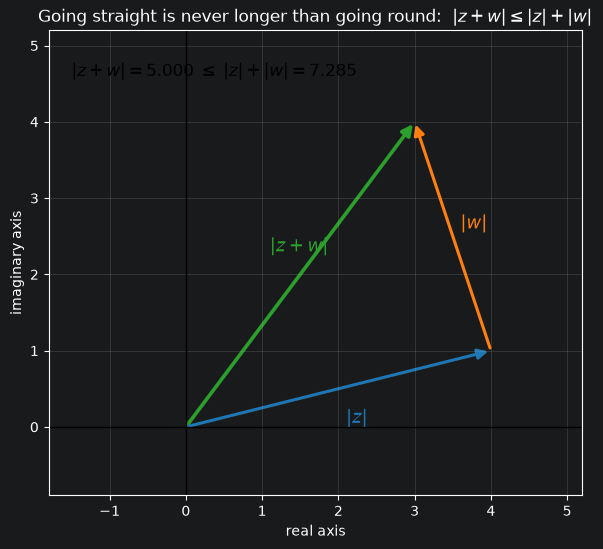

In [6]:
# --- Figure 6: the triangle inequality, drawn ---

fig, ax = plt.subplots(figsize=(7.2, 5.6))

z = 4 + 1j          # first step
w = -1 + 3j         # second step
s = z + w           # the total

# the direct way from 0 to z+w (the straight route)
ax.add_patch(FancyArrowPatch((0, 0), (s.real, s.imag), arrowstyle="-|>",
                             mutation_scale=16, linewidth=2.6, color=C_GOOD))
# the route through z: first z, then w starting at the tip of z
ax.add_patch(FancyArrowPatch((0, 0), (z.real, z.imag), arrowstyle="-|>",
                             mutation_scale=15, linewidth=2.2, color=C_MAIN))
ax.add_patch(FancyArrowPatch((z.real, z.imag), (s.real, s.imag), arrowstyle="-|>",
                             mutation_scale=15, linewidth=2.2, color=C_ALT))

ax.text(z.real / 2 + 0.1, z.imag / 2 - 0.45, r"$|z|$",     fontsize=13, color=C_MAIN)
ax.text(3.6, 2.6,                              r"$|w|$",     fontsize=13, color=C_ALT)
ax.text(1.1, 2.3,                              r"$|z+w|$",   fontsize=13, color=C_GOOD)

# abs() gives the modulus, so we can print the actual numbers and check the inequality
ax.text(-1.5, 4.6,
        r"$|z+w| = %.3f \;\leq\; |z|+|w| = %.3f$" % (abs(s), abs(z) + abs(w)),
        fontsize=12, color="black")

ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlim(-1.8, 5.2)
ax.set_ylim(-0.9, 5.2)
ax.set_aspect("equal")            # lengths must be comparable by eye
ax.grid(alpha=0.25)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.set_title("Going straight is never longer than going round:  "
             r"$|z+w| \leq |z|+|w|$", fontsize=12)
plt.tight_layout()
plt.show()

### 3.4 Powers of $i$

**Theorem 8 (the powers of $i$ repeat with period 4).** For every integer $n \ge 0$,

$$i^{n} = \begin{cases}
1 & \text{if } n \equiv 0 \pmod 4,\\
i & \text{if } n \equiv 1 \pmod 4,\\
-1 & \text{if } n \equiv 2 \pmod 4,\\
-i & \text{if } n \equiv 3 \pmod 4.
\end{cases}$$

The symbol $n\equiv r \pmod 4$ means "$n$ leaves remainder $r$ when divided by $4$".

**Proof.** First the four small cases, straight from Theorem 2:
$$i^{0}=1,\qquad i^{1}=i,\qquad i^{2}=-1,\qquad i^{3}=i^{2}\cdot i = -i .$$
Next,
$$i^{4} = i^{2}\cdot i^{2} = (-1)(-1) = 1 .$$

Now take any $n\ge0$. By the division algorithm (nb 06) write $n = 4q+r$ with $q\ge0$ an
integer and $r\in\{0,1,2,3\}$. Then, using the exponent laws (nb 02 — valid here because
Theorem 1 gives us associativity and commutativity):
$$i^{n} = i^{4q+r} = \left(i^{4}\right)^{q}\cdot i^{r} = 1^{q}\cdot i^{r} = i^{r} .$$
And $i^{r}$ is one of the four values listed above. $\blacksquare$

**Method.** To compute $i^{2026}$: divide $2026$ by $4$. $2026 = 4\cdot 506 + 2$, so
$i^{2026} = i^{2} = -1$. You never multiply $2026$ times. Figure 7 shows why the pattern must
repeat: each multiplication by $i$ is a quarter turn, and four quarter turns bring you home.

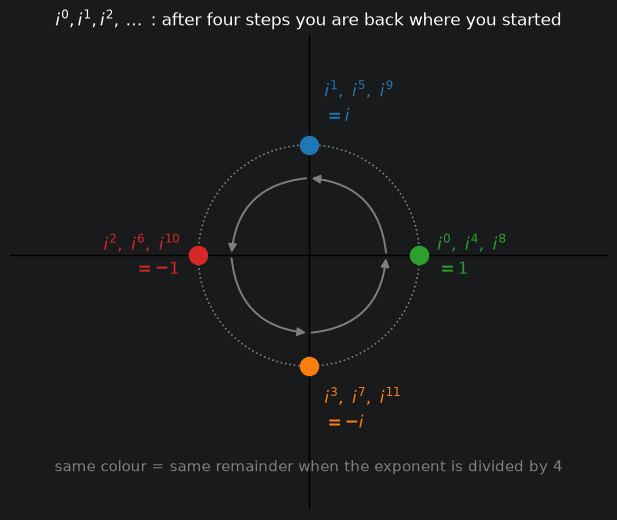

In [7]:
# --- Figure 7: the powers of i walk around the circle and come back ---

fig, ax = plt.subplots(figsize=(6.4, 6.4))

ax.add_patch(Circle((0, 0), 1.0, fill=False, edgecolor=C_GREY,
                    linestyle=":", linewidth=1.2))

# the four places a power of i can land, with the value at each place
spots  = [(1, 0), (0, 1), (-1, 0), (0, -1)]
values = [r"$=1$", r"$=i$", r"$=-1$", r"$=-i$"]
colours = [C_GOOD, C_MAIN, C_BAD, C_ALT]
# how far outside the circle the label goes, and how the text is anchored
places = [(1.16, 0, "left", "center"), (0.14, 1.16, "left", "bottom"),
          (-1.16, 0, "right", "center"), (0.14, -1.16, "left", "top")]

# start at 1 and multiply by i again and again, twelve times in all
p = 1 + 0j
landed = [[], [], [], []]          # which exponents land on each of the four spots
for n in range(12):
    landed[n % 4].append(n)
    p = p * 1j                     # one more quarter turn

for k in range(4):
    x, y = spots[k]
    ax.plot(x, y, "o", color=colours[k], markersize=13, zorder=3)
    # write all the exponents that land here on one line, then the value below it
    expo = ",\\ ".join(r"i^{%d}" % n for n in landed[k])
    lx, ly, ha, va = places[k]
    ax.text(lx, ly, "$" + expo + "$\n" + values[k], fontsize=12,
            ha=ha, va=va, color=colours[k], linespacing=1.5)

# four curved arrows showing the order of the walk: 1 -> i -> -1 -> -i -> 1
for k in range(4):
    x0, y0 = spots[k]
    x1, y1 = spots[(k + 1) % 4]
    ax.add_patch(FancyArrowPatch((x0 * 0.70, y0 * 0.70), (x1 * 0.70, y1 * 0.70),
                                 connectionstyle="arc3,rad=0.42",
                                 arrowstyle="-|>", mutation_scale=12,
                                 linewidth=1.4, color=C_GREY))

ax.text(0, -1.95, "same colour = same remainder when the exponent is divided by 4",
        fontsize=11, ha="center", color=C_GREY)
ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlim(-2.7, 2.7)
ax.set_ylim(-2.3, 2.0)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title(r"$i^0,i^1,i^2,\dots$ : after four steps you are back where you started",
             fontsize=12)
plt.tight_layout()
plt.show()

### 3.5 A surprise: complex numbers cannot be put in order

This theorem is not in most school books, and it should be. It answers a question you should
already be asking: *is $i$ bigger or smaller than $1$?*

**Theorem 9 ($\mathbb{C}$ is not an ordered field).** There is **no** relation $<$ on
$\mathbb{C}$ satisfying the order axioms of notebook 01, namely:

* (O1, trichotomy) for every $z$, exactly one of $z<0$, $z=0$, $0<z$ holds;
* (O2) if $0<z$ and $0<w$ then $0<z+w$;
* (O3) if $0<z$ and $0<w$ then $0<zw$.

**Proof (by contradiction).** Suppose such a $<$ exists.

*Step 1: every non-zero square is positive.* Take $z\ne0$. By (O1) either $0<z$ or $z<0$.
 - If $0<z$, then (O3) with $w=z$ gives $0<z^{2}$.
 - If $z<0$, then $0<-z$ (add $-z$ to both sides — a standard consequence of the axioms, nb
   01), so (O3) applied to $-z$ gives $0<(-z)(-z) = z^{2}$, since $(-z)(-z)=z^{2}$ by the
   sign rules, which follow from the field axioms and so hold here by Theorem 1.

 Either way, $0 < z^{2}$.

*Step 2: apply Step 1 twice.*
 - $1\ne0$ and $1 = 1^{2}$, so $0<1$.
 - $i\ne0$, so $0<i^{2} = -1$ by Theorem 2. That is, $0<-1$.

*Step 3: the contradiction.* From $0<1$ and $0<-1$, axiom (O2) gives
$$0 < 1+(-1) = 0,$$
so $0<0$. But (O1) says exactly one of $0<0$, $0=0$, $0>0$ holds, and $0=0$ is true. So
$0<0$ is false. Contradiction. Therefore no such order exists. $\blacksquare$

**What this means, in words.** You may **never** write $z<w$ for complex numbers. Not because
it is hard, or because nobody has found the right definition yet — because it is
**impossible**. Any definition you invent will break one of the three rules.

Three consequences you should carry with you:

1. There is no "positive" square root of $-1$. $i$ and $-i$ are twins with no way to tell
   which is bigger. That is why Definition 8 is a *choice*.
2. Inequalities (notebook 13, coming soon) will live in $\mathbb{R}$ forever. Complex numbers
   are for equations, not for inequalities.
3. But $|z|$ **is** a real number, so *sizes* of complex numbers can always be compared. When
   you want to say "this complex number is small", you must say $|z|$ is small.

### 3.6 Square roots of negative numbers — and the trap

**Theorem 10 (the two square roots of a negative real).** Let $N>0$ be real. Then the
equation $x^{2}=-N$ has exactly two solutions in $\mathbb{C}$:

$$x = i\sqrt{N} \quad\text{and}\quad x = -i\sqrt{N}.$$

**Proof.** *They are solutions.* Using Theorem 1 (we may reorder a product) and Theorem 2:
$$\left(i\sqrt N\right)^{2} = i^{2}\left(\sqrt N\right)^{2} = (-1)\cdot N = -N,$$
because $(\sqrt N)^{2}=N$ for $N \ge 0$ (nb 08). The same computation with $-i$ gives
$(-i\sqrt N)^{2} = (-i)^{2}N = (-1)N = -N$.

*There are no others.* Suppose $x^{2}=-N$. Then
$$x^{2}-\left(i\sqrt N\right)^{2}=0 .$$
The difference of squares (nb 04 Thm 3) is an identity proved from the field axioms, so by
Theorem 1 it is valid in $\mathbb{C}$:
$$\left(x-i\sqrt N\right)\left(x+i\sqrt N\right)=0 .$$
By the zero-product property, which holds in $\mathbb{C}$ (consequence of Theorem 6),
$x = i\sqrt N$ or $x=-i\sqrt N$. $\blacksquare$

By **Definition 8** we write $\sqrt{-N} := i\sqrt N$ for the first of the two.

---

**Theorem 10b (the rule $\sqrt{ab}=\sqrt a\sqrt b$ is FALSE for negative numbers).**

**Proof — one counterexample is enough** (this is how you disprove a general statement):

$$\sqrt{-4}\cdot\sqrt{-9} = (2i)(3i) = 6i^{2} = -6,$$
$$\text{but}\qquad \sqrt{(-4)(-9)} = \sqrt{36} = 6 .$$

And $-6 \ne 6$. $\blacksquare$

**This is the most common mistake in the whole topic**, and it is worth understanding rather
than fearing. Go back to notebook 02 Theorem 9 and read its statement:

> for $a\ge0$ **and** $b\ge0$: $\sqrt{ab}=\sqrt a\sqrt b$.

The hypothesis "$a\ge0$ and $b\ge0$" was always there. We never needed it before, because we
never had a negative number under a root. A theorem outside its hypotheses is not a weaker
theorem — it is **not a theorem at all**.

**The safe habit:** convert every negative root to $i$ **first**, then multiply.

$$\sqrt{-4}\cdot\sqrt{-9} \;\longrightarrow\; (2i)(3i) \;\longrightarrow\; 6i^{2}=-6 .$$

If you always do this, you can never be caught.

---

### 3.7 Quadratic equations over $\mathbb{C}$

Now we redo notebook 10, and this time nothing stops us.

**Theorem 11 (the quadratic formula in $\mathbb{C}$, real coefficients).**
Let $a,b,c$ be **real** with $a\ne0$, and let $D=b^{2}-4ac$. Then in $\mathbb{C}$ the equation
$ax^{2}+bx+c=0$ has exactly the solutions

$$x = \frac{-b\pm\sqrt{D}}{2a} \quad (D\ge0), \qquad\qquad
  x = \frac{-b\pm i\sqrt{-D}}{2a} \quad (D<0),$$

and in the case $D<0$ the two solutions are **conjugates of each other**, and neither is real.

**Proof.** Follow notebook 10 Theorem 4 exactly. Every step there used only the field axioms,
so by Theorem 1 every step is still legal in $\mathbb{C}$. Multiply by $4a$ (allowed:
$4a\ne0$) and complete the square:

$$4a^{2}x^{2}+4abx+4ac=0 \;\Longrightarrow\; (2ax+b)^{2} - b^{2} + 4ac = 0
 \;\Longrightarrow\; (2ax+b)^{2} = D .$$

Now — and this is the only new step — the square-root property must be re-proved in
$\mathbb{C}$, because notebook 10 Theorem 2 had three cases and the third one said "no
solution". Here is the replacement.

*Claim: in $\mathbb{C}$, $u^{2}=D$ has exactly two solutions when $D \ne 0$, and one when
$D=0$.*
 - If $D>0$: $u^{2}-(\sqrt D)^{2}=0$, so $(u-\sqrt D)(u+\sqrt D)=0$, so $u=\pm\sqrt D$.
 - If $D=0$: $u^{2}=0$ forces $u=0$ (zero-product property with $u\cdot u = 0$).
 - If $D<0$: write $D = -(-D)$ where $-D>0$. By Theorem 10, $u=\pm i\sqrt{-D}$.

Substituting $u=2ax+b$ and solving the linear equation for $x$ (nb 09) gives, in the case
$D<0$,
$$2ax+b = \pm i\sqrt{-D} \;\Longrightarrow\; x = \frac{-b\pm i\sqrt{-D}}{2a}.$$

Every step above is reversible (we only added, subtracted, multiplied and divided by non-zero
numbers), so these are exactly the solutions and there are no others.

*They are conjugates.* Write $\alpha = \dfrac{-b}{2a} + \dfrac{\sqrt{-D}}{2a}\,i$. Since
$a,b,D$ are real and $-D>0$, both $\dfrac{-b}{2a}$ and $\dfrac{\sqrt{-D}}{2a}$ are **real**
numbers, so this is standard form (Definition 4), and the other solution is
$\dfrac{-b}{2a} - \dfrac{\sqrt{-D}}{2a}\,i = \bar\alpha$.

*Neither is real.* Their imaginary part is $\pm\dfrac{\sqrt{-D}}{2a}$, and $\sqrt{-D}>0$
because $-D>0$; also $2a\ne0$. So the imaginary part is not zero. $\blacksquare$

**Notice what did and did not change.** The formula did not change. The discriminant did not
change. Only the *reading* of case 3 changed: "no real solution" became "two solutions that
are not real". Notebook 10 was not wrong; it was answering a question about $\mathbb{R}$.

---

**Theorem 12 (notebook 10, repaired).** Let $a,b,c$ be real, $a \ne 0$, and let
$\alpha,\beta$ be the two solutions from Theorem 11 (with $\alpha=\beta$ when $D=0$). Then,
**with no condition on $D$ at all**:

1. (Vieta) $\alpha+\beta = -\dfrac{b}{a}$ and $\alpha\beta = \dfrac{c}{a}$;
2. (Factorisation) $ax^{2}+bx+c = a(x-\alpha)(x-\beta)$ for every $x\in\mathbb{C}$;
3. counted with multiplicity, the equation has **exactly two** roots in $\mathbb{C}$.

**Proof.** (1) Add and multiply the two formulas. Write $\alpha=\frac{-b+u}{2a}$,
$\beta=\frac{-b-u}{2a}$, where $u=\sqrt D$ if $D\ge0$ and $u=i\sqrt{-D}$ if $D<0$. In both
cases $u^{2}=D$ — that is the whole point, and it is why one calculation now covers both
cases. Then
$$\alpha+\beta = \frac{(-b+u)+(-b-u)}{2a} = \frac{-2b}{2a} = -\frac{b}{a},$$
$$\alpha\beta = \frac{(-b+u)(-b-u)}{4a^{2}} = \frac{b^{2}-u^{2}}{4a^{2}}
 = \frac{b^{2}-D}{4a^{2}} = \frac{b^{2}-(b^{2}-4ac)}{4a^{2}} = \frac{4ac}{4a^{2}}
 = \frac{c}{a},$$
using the difference of squares (valid by Theorem 1).

(2) Expand the right side and use part (1):
$$a(x-\alpha)(x-\beta) = a\left(x^{2}-(\alpha+\beta)x+\alpha\beta\right)
 = a\left(x^{2}+\frac{b}{a}x+\frac{c}{a}\right) = ax^{2}+bx+c .$$

(3) By (2) and the zero-product property, $ax^{2}+bx+c=0$ exactly when $x=\alpha$ or
$x=\beta$. If $D\ne0$ these are two different numbers (their difference is $u/a\ne0$); if
$D=0$ then $\alpha=\beta$ and the factorisation reads $a(x-\alpha)^{2}$, so $\alpha$ has
multiplicity $2$ (Definition 9). Either way the count is $2$. $\blacksquare$

**This is the repair.** In notebook 10 these two results carried the condition $D\ge0$, and
that condition has now vanished. The scar is healed. A statement with fewer hypotheses is a
better statement — and it is also easier to remember.

---

**Theorem 13 (conjugate root theorem).** Let
$$p(x) = a_{n}x^{n}+a_{n-1}x^{n-1}+\dots+a_{1}x+a_{0}$$
be a polynomial whose coefficients $a_{k}$ are all **real**. If $z\in\mathbb{C}$ is a root of
$p$, then $\bar z$ is also a root.

*In words: for a real polynomial, non-real roots always come in twin pairs.*

**Proof.** Assume $p(z)=0$. Take the conjugate of both sides:
$$\overline{p(z)} = \bar 0 = 0 .$$
Now compute $\overline{p(z)}$ using Theorem 5. First, the conjugate of a sum is the sum of the
conjugates (Thm 5(1), extended to $n+1$ terms by induction — exactly the induction technique
of notebook 02):
$$\overline{p(z)} = \overline{a_{n}z^{n}} + \overline{a_{n-1}z^{n-1}} + \dots + \overline{a_{0}} .$$
Next, the conjugate of a product is the product of the conjugates (Thm 5(2), again extended by
induction), so $\overline{a_{k}z^{k}} = \overline{a_{k}}\cdot\overline{z}^{\,k}$.
Finally, each $a_{k}$ is **real**, so $\overline{a_{k}} = a_{k}$ by Theorem 5(6). Putting
these together,
$$0 = \overline{p(z)} = a_{n}\bar z^{\,n} + a_{n-1}\bar z^{\,n-1} + \dots + a_{0} = p(\bar z).$$
So $\bar z$ is a root. $\blacksquare$

**Where the hypothesis lives.** The proof uses "the coefficients are real" in exactly one
place: $\overline{a_k}=a_k$. Remove it and the theorem dies. Counterexample: $p(x)=x-i$ has
the root $i$, but $p(-i) = -2i \ne 0$. Trap 7 below.

**Consequence (used in Example 11).** If you want a quadratic with **real** coefficients and
you know one non-real root, then the other root is forced: it must be the conjugate. You have
no freedom.

### 3.8 Every complex number has a square root

Theorem 11 handled real coefficients. What if the coefficients are themselves complex? Then
$D$ is a complex number, and to use the formula we need $\sqrt D$ to *exist*. It does — and
the proof is a construction, so it also tells you how to compute it by hand.

**Theorem 14 (square roots in $\mathbb{C}$).** Every $w\in\mathbb{C}$ has a square root: there
is a $z\in\mathbb{C}$ with $z^{2}=w$. If $w\ne0$ there are exactly two such $z$, and they are
$z$ and $-z$.

**Proof.** If $w=0$, then $z=0$ works, and $z^2=0$ forces $z=0$ by the zero-product property.
So let $w = p+qi \ne 0$ with $p,q$ real, and look for $z=x+yi$ with $x,y$ real.

$$z^{2} = (x+yi)^{2} = x^{2}-y^{2} + 2xy\,i .$$

By Theorem 3 (uniqueness of standard form), $z^{2}=w$ is the same as **two real equations**:

$$x^{2}-y^{2}=p \qquad\text{and}\qquad 2xy=q. \tag{$*$}$$

Here is the trick that makes it work. Take moduli in $z^2 = w$ and use Theorem 7(3):
$|z|^{2}=|w|$, that is,
$$x^{2}+y^{2} = \sqrt{p^{2}+q^{2}} =: r \qquad (r>0). \tag{$**$}$$

Now add and subtract the first equation of $(*)$ and equation $(**)$:

$$2x^{2} = r+p \quad\Longrightarrow\quad x^{2} = \frac{r+p}{2},$$
$$2y^{2} = r-p \quad\Longrightarrow\quad y^{2} = \frac{r-p}{2}.$$

Both right-hand sides are $\ge0$. Why: $r=\sqrt{p^{2}+q^{2}}\ge\sqrt{p^{2}}=|p|$ (the number
under the root only got bigger, and $\sqrt{\ }$ keeps the order — nb 08 Thm 5). And
$|p|\ge p$ as well as $|p|\ge -p$, by the definition of absolute value (nb 01). So
$r+p\ge0$ and $r-p\ge0$. Therefore we may take real square roots:

$$x = \pm\sqrt{\frac{r+p}{2}}, \qquad y = \pm\sqrt{\frac{r-p}{2}} .$$

Finally the two signs are not independent: the second equation of $(*)$, $2xy=q$, says that
$xy$ must have the **same sign as $q$**. So choose the signs of $x$ and $y$ so that $xy$ and
$q$ agree in sign (if $q=0$ then one of $x,y$ is $0$ and there is nothing to choose).

That gives a $z$ with $z^{2}=w$; the opposite choice of both signs gives $-z$, and
$(-z)^{2}=z^{2}=w$ as well.

*No others.* If $z_{1}^{2}=w=z^{2}$ then $z_{1}^{2}-z^{2}=0$, so $(z_{1}-z)(z_{1}+z)=0$, so
$z_{1}=z$ or $z_{1}=-z$ by the zero-product property. $\blacksquare$

**Consequence (Theorem 14b).** *Every* quadratic equation $az^{2}+bz+c=0$ with **complex**
coefficients and $a\ne0$ has exactly two roots in $\mathbb{C}$, counted with multiplicity,
given by the same formula
$$z = \frac{-b\pm\sqrt{D}}{2a}, \qquad D=b^{2}-4ac,$$
where $\sqrt D$ now means *either one* of the two square roots of $D$ given by Theorem 14
(the $\pm$ covers the other). The derivation of Theorem 11 goes through word for word,
because the only thing it needed was that $u^{2}=D$ has a solution. Worked example 16 does a
full one by hand.

---

### 3.9 The honest gap: the Fundamental Theorem of Algebra

We have proved: degree 1 always has a root (nb 09), and degree 2 always has two roots
(Theorem 14b). What about degree 3, 4, 100?

**Theorem 15 (Fundamental Theorem of Algebra — STATED, NOT PROVED HERE).**
Every polynomial of degree $n\ge1$ with complex coefficients has at least one root in
$\mathbb{C}$. Combined with the factor theorem (nb 05) and induction, this gives: every such
polynomial factors completely,
$$p(x) = a_{n}(x-r_{1})(x-r_{2})\cdots(x-r_{n}),$$
so it has **exactly $n$ roots in $\mathbb{C}$**, counted with multiplicity.

**Why I am not proving it.** Every known proof needs tools we have not built: continuity,
limits, and a theorem saying that a continuous function on a closed bounded region reaches
its smallest value. Those belong to analysis, several chapters away. Proving it now would
mean asking you to accept three unproved things in order to prove one — which is worse than
being honest.

**What I promise instead:** when we have those tools, we come back and prove it. Mark this
page.

**What depends on it, and what does not.** Everything else in this notebook is proved in
full and does **not** use Theorem 15. Theorem 15 is used only for statements about degree
$\ge 3$: for example, "a real polynomial of odd degree has at least one real root" (because
by Theorem 13 the non-real roots pair up, so an odd number of roots cannot all be paired).
Any exercise that needs Theorem 15 will say so.

**Why the name.** It is called *fundamental* because it closes the story that started in
§1.1. Extending $\mathbb{N}\to\mathbb{Z}\to\mathbb{Q}\to\mathbb{R}$ each time left new
unsolvable equations behind. This time it does not: **$\mathbb{C}$ needs no successor.** Every
polynomial equation, with any complex coefficients, already has all its solutions inside
$\mathbb{C}$. The tower of Figure 1 stops here — and that is a genuinely surprising fact.

---

## 4. The traps (read this section twice)

**Trap 1 — the radical rule.** $\sqrt{-4}\cdot\sqrt{-9} \ne \sqrt{36}$. The truth is $-6$.
The rule $\sqrt{ab}=\sqrt a\sqrt b$ needs $a\ge0$ **and** $b\ge0$ (nb 02 Thm 9).
*Cure:* turn every negative root into $i$ **before** you multiply anything.

**Trap 2 — "the" square root of $-1$.** Both $i$ and $-i$ square to $-1$. Writing
$\sqrt{-1}=i$ is a **choice of notation** (Definition 8), not a fact. Never argue that $i$
is "the positive one" — Theorem 9 says positivity does not exist here.

**Trap 3 — the imaginary part is real.** $\operatorname{Im}(3-2i) = -2$, **not** $-2i$ and
**not** $2$. And in $a+bi$, both $a$ and $b$ must be real numbers, or it is not standard form.

**Trap 4 — you may not compare complex numbers.** $i<2$ is not false; it is **meaningless**
(Theorem 9). But $|i|<|2|$ is a perfectly good true statement about two real numbers.

**Trap 5 — the modulus is not "delete the minus sign".** $|3-4i| = \sqrt{9+16} = 5$, not
$3+4i$ and not $3-4i$. It is a length, so it is always a single non-negative **real** number.

**Trap 6 — $i$ in a denominator is not a finished answer.** $\dfrac{1}{i}$ must be cleaned:
$$\frac1i = \frac{1}{i}\cdot\frac{-i}{-i} = \frac{-i}{-i^{2}} = \frac{-i}{1} = -i .$$
Always finish in standard form $a+bi$.

**Trap 7 — the conjugate root theorem needs REAL coefficients.** $x-i=0$ has the root $i$ and
$-i$ is not a root. $x^{2}-(3+i)x+(2+2i)=0$ has roots $2$ and $1+i$ — not conjugates. Check
the hypothesis before you use the theorem. (This is the same failure mode as nb 10 Ex 7(d),
and as nb 08 Ex 12.)

**Trap 8 — powers of $i$ by hand.** $i^{2026}$ is not "multiply 2026 times" and not
"$i^{2}$ because it ends in 26". Divide the exponent by $4$ and keep the remainder
(Theorem 8). $2026 = 4\cdot506+2$, so the answer is $-1$.

**Trap 9 — "no solution" now depends on the question.** For $x^{2}+1=0$:
*solve in $\mathbb{R}$* has answer $S=\varnothing$; *solve in $\mathbb{C}$* has answer
$S=\{i,-i\}$. Both are correct answers to different questions. **Always write which set you
are solving in.** If the problem does not say, say what you assumed.

**Trap 10 — $D$ still means what it meant.** $D<0$ does not mean "no answer" and it does not
mean "the answer is complex and messy". It means precisely: *the two roots are a conjugate
pair, and neither is real* (Theorem 11). $D$ is still computed from real $a,b,c$ in the
usual way.

**Trap 11 — Python.** `math.sqrt(-1)` raises an error; `cmath.sqrt(-1)` gives `1j`. And in
Python the imaginary unit is written `1j`, never `j` on its own and never `i`. Also `1j**2`
prints `(-1+0j)`: the `+0j` is Python saying "still a complex number, with imaginary part
zero", not a mistake.

---

## 5. Worked examples

Each one is done by hand first. The Python check comes after all of them, in one cell, so
that you can cover the screen and try the example yourself before looking.

### Example 1 — add and subtract

Compute $(3+2i)+(5-7i)$ and $(3+2i)-(5-7i)$.

Add the real parts, add the imaginary parts (Theorem 4):

$$(3+2i)+(5-7i) = (3+5) + (2-7)i = 8 - 5i .$$
$$(3+2i)-(5-7i) = (3-5) + (2-(-7))i = -2 + 9i .$$

*The subtraction is where signs die.* $-(-7i) = +7i$.

---

### Example 2 — multiply

Compute $(2+3i)(4-5i)$.

Expand normally (Theorem 1 allows it), then use $i^{2}=-1$:

$$(2+3i)(4-5i) = 8 - 10i + 12i - 15i^{2} = 8 + 2i - 15(-1) = 23 + 2i .$$

Note the sign flip: $-15i^{2}$ became $+15$. That single step is where the "$-bd$" in the
formula of Theorem 4 comes from.

---

### Example 3 — a power of $i$

Compute $i^{2026}$ and $i^{-3}$.

$2026 = 4\cdot 506 + 2$, remainder $2$, so by Theorem 8, $i^{2026} = i^{2} = -1$.

For the negative exponent, use the exponent laws (valid by Theorem 1) and Trap 6:
$$i^{-3} = \frac{1}{i^{3}} = \frac{1}{-i} = \frac{1}{-i}\cdot\frac{i}{i}
        = \frac{i}{-i^{2}} = \frac{i}{1} = i .$$
Check against the pattern: $i^{-3}=i^{-3+4}=i^{1}=i$. $\checkmark$

---

### Example 4 — conjugate and modulus

For $z=3-4i$: $\ \bar z = 3+4i$, and

$$|z| = \sqrt{3^{2}+(-4)^{2}} = \sqrt{9+16} = \sqrt{25} = 5 .$$

Check with Theorem 5(4): $z\bar z = (3-4i)(3+4i) = 9 + 12i - 12i - 16i^{2} = 9+16 = 25 = |z|^{2}$.
$\checkmark$ ($3,4,5$ — the Pythagorean triple from notebook 03, back again.)

---

### Example 5 — divide

Compute $\dfrac{2+3i}{4-i}$.

Multiply top and bottom by the **conjugate of the bottom**, $4+i$ (Theorem 6):

$$\frac{2+3i}{4-i}\cdot\frac{4+i}{4+i}
 = \frac{(2+3i)(4+i)}{(4-i)(4+i)} .$$

Top: $\;8 + 2i + 12i + 3i^{2} = 8 + 14i - 3 = 5 + 14i$.
Bottom: $\;4^{2}+1^{2} = 17$ (Theorem 5(4) — no expansion needed, and it is always real).

$$\frac{2+3i}{4-i} = \frac{5+14i}{17} = \frac{5}{17} + \frac{14}{17}\,i .$$

Standard form means **split the fraction**: real part $\frac5{17}$, imaginary part
$\frac{14}{17}$.

---

### Example 6 — powers by squaring, and the rotation

Compute $(1+i)^{2}$, $(1+i)^{4}$, $(1+i)^{8}$.

$$(1+i)^{2} = 1 + 2i + i^{2} = 1 + 2i - 1 = 2i .$$
$$(1+i)^{4} = \left((1+i)^{2}\right)^{2} = (2i)^{2} = 4i^{2} = -4 .$$
$$(1+i)^{8} = \left((1+i)^{4}\right)^{2} = (-4)^{2} = 16 .$$

Never multiply eight times. And look at the moduli: $|1+i|=\sqrt{2}$, and
$|(1+i)^{8}| = 16 = (\sqrt{2})^{8}$, exactly as Theorem 7(3) demands.

---

### Example 7 — negative radicals, safely

$$\sqrt{-49} = i\sqrt{49} = 7i, \qquad \sqrt{-12} = i\sqrt{12} = 2i\sqrt{3} .$$

And the trap, done correctly:
$$\sqrt{-2}\cdot\sqrt{-8} = \left(i\sqrt{2}\right)\left(i\sqrt{8}\right)
 = i^{2}\sqrt{16} = -4 .$$
(The careless answer $\sqrt{16}=4$ has the wrong sign.)

---

### Example 8 — the simplest complex equation

Solve $x^{2}+9=0$ **in $\mathbb{C}$**.

$$x^{2} = -9 \;\Longrightarrow\; x = \pm i\sqrt{9} = \pm 3i \qquad\text{(Theorem 10)} .$$

$$S = \{3i,\ -3i\} .$$

In $\mathbb{R}$ the answer would be $S=\varnothing$ (Trap 9).

---

### Example 9 — a real quadratic with $D<0$

Solve $x^{2}-4x+13=0$ in $\mathbb{C}$.

$a=1,\ b=-4,\ c=13$, so
$$D = (-4)^{2}-4(1)(13) = 16-52 = -36 < 0 .$$
Theorem 11, case $D<0$:
$$x = \frac{4 \pm i\sqrt{36}}{2} = \frac{4\pm 6i}{2} = 2 \pm 3i .$$

$$S = \{2+3i,\ 2-3i\} .$$

**Divide every term** — $\frac{4\pm6i}{2} = 2\pm3i$, not $4\pm3i$. (That is nb 10 Trap 5,
alive and well.) The two roots are conjugates, as Theorem 11 promised.

*Check by substitution:*
$$(2+3i)^{2} = 4+12i+9i^{2} = -5+12i, \qquad -4(2+3i) = -8-12i,$$
$$(-5+12i)+(-8-12i)+13 = 0 . \;\checkmark$$

---

### Example 10 — fractions in the answer

Solve $3x^{2}+2x+1=0$ in $\mathbb{C}$.

$D = 4 - 12 = -8$. So
$$x = \frac{-2\pm i\sqrt{8}}{6} = \frac{-2 \pm 2i\sqrt{2}}{6}
    = \frac{-1\pm i\sqrt{2}}{3} = -\frac13 \pm \frac{\sqrt{2}}{3}\,i .$$

Simplify $\sqrt{8} = 2\sqrt{2}$ (nb 08) and cancel the common factor $2$ from **all three**
places. Keep the answer exact: no decimals.

---

### Example 11 — build a real quadratic from one complex root

Find a quadratic equation with **real** coefficients, one of whose roots is $5-2i$.

By Theorem 13 the other root **must** be $5+2i$ — we have no choice. Now use Vieta
(Theorem 12):

$$\text{sum} = (5-2i)+(5+2i) = 10, \qquad
  \text{product} = (5-2i)(5+2i) = 25+4 = 29 .$$

(The product used Theorem 5(4): $z\bar z = |z|^2 = 25+4$.) A monic quadratic with these roots
is
$$x^{2} - (\text{sum})x + (\text{product}) = 0 \;\Longrightarrow\; x^{2}-10x+29 = 0 .$$

Check: $D = 100-116 = -16<0$, and $x = \frac{10\pm 4i}{2} = 5\pm2i$. $\checkmark$

Note how the conjugate pair made the irrational/imaginary parts cancel — exactly the same
phenomenon as nb 10 Example 10 with $\sqrt{2}$.

---

### Example 12 — factor completely over $\mathbb{C}$

(a) $x^{2}+4$. Over $\mathbb{R}$ this is irreducible (nb 05). Over $\mathbb{C}$:
$$x^{2}+4 = x^{2}-(2i)^{2} = (x-2i)(x+2i).$$

(b) $x^{4}-1$. Difference of squares twice:
$$x^{4}-1 = (x^{2}-1)(x^{2}+1) = (x-1)(x+1)(x-i)(x+i).$$
Four factors, four roots: $1,-1,i,-i$ — the four numbers of Figure 2, and exactly $n=4$ roots
as Theorem 15 predicts.

(c) $x^{4}+4$. This one has **no real roots at all**, yet it factors. Add and subtract
$4x^{2}$:
$$x^{4}+4 = x^{4}+4x^{2}+4-4x^{2} = (x^{2}+2)^{2}-(2x)^{2} = (x^{2}-2x+2)(x^{2}+2x+2).$$
Each factor has $D=4-8=-4<0$, giving roots $1\pm i$ and $-1\pm i$. Four roots again, in two
conjugate pairs, as Theorem 13 demands.

---

### Example 13 — the three cube roots of $1$

Solve $x^{3}=1$ in $\mathbb{C}$.

Move everything to one side and factor (nb 05, the identity
$u^{3}-v^{3}=(u-v)(u^{2}+uv+v^{2})$):
$$x^{3}-1 = (x-1)(x^{2}+x+1) = 0 .$$
By the zero-product property, $x=1$ or $x^{2}+x+1=0$. For the quadratic, $D = 1-4 = -3$, so
$$x = \frac{-1\pm i\sqrt{3}}{2}.$$

$$S = \left\{\,1,\ \ -\tfrac12 + \tfrac{\sqrt{3}}{2}i,\ \ -\tfrac12 - \tfrac{\sqrt{3}}{2}i \,\right\}.$$

Three roots for a cubic. And each has modulus
$\sqrt{\tfrac14+\tfrac34} = 1$: all three sit on the unit circle. Figure 9 draws them, and
you will see they are equally spaced — a hint of the beautiful theory that arrives with
trigonometry.

---

### Example 14 — a square root of a complex number, by hand

Find all $z$ with $z^{2} = 3+4i$.

Follow the proof of Theorem 14 with $p=3$, $q=4$:
$$r = \sqrt{p^{2}+q^{2}} = \sqrt{9+16} = 5 .$$
$$x^{2} = \frac{r+p}{2} = \frac{5+3}{2} = 4, \qquad
  y^{2} = \frac{r-p}{2} = \frac{5-3}{2} = 1 .$$
So $x=\pm2$, $y=\pm1$. The sign condition is $2xy = q = 4 > 0$, so $x$ and $y$ must have the
**same** sign. Therefore
$$z = 2+i \qquad\text{or}\qquad z = -2-i .$$

Check: $(2+i)^{2} = 4+4i+i^{2} = 3+4i$. $\checkmark$

---

### Example 15 — a quadratic with complex coefficients

Solve $z^{2}-(3+i)z+(2+2i)=0$ in $\mathbb{C}$.

Theorem 13 does **not** apply (the coefficients are not real), so do not expect a conjugate
pair. Use Theorem 14b.

$$D = (3+i)^{2}-4(2+2i) = (9+6i-1) - (8+8i) = (8+6i)-(8+8i) = -2i .$$

Now we need a square root of $-2i$, by Theorem 14 with $p=0$, $q=-2$:
$$r=\sqrt{0+4}=2, \qquad x^{2}=\frac{2+0}{2}=1, \qquad y^{2}=\frac{2-0}{2}=1 .$$
So $x=\pm1$, $y=\pm1$, and $2xy=q=-2<0$ forces **opposite** signs. Take $\sqrt D = 1-i$
(check: $(1-i)^{2} = 1-2i+i^{2} = -2i$ $\checkmark$).

$$z = \frac{(3+i) \pm (1-i)}{2} .$$

$$z_{1} = \frac{4+0i}{2} = 2, \qquad z_{2} = \frac{2+2i}{2} = 1+i .$$

$$S=\{2,\ 1+i\}.$$

Look: one root is real, the other is not, and they are **not** conjugates. That is legal here
and impossible for real coefficients. Trap 7, seen from the inside.

*Check with Vieta:* sum $= 2+(1+i) = 3+i$ $\checkmark$; product $= 2(1+i) = 2+2i$ $\checkmark$.

---

### Example 16 — reading the discriminant for information

Without solving, say what kind of roots each equation has, in $\mathbb{R}$ and in $\mathbb{C}$.

| Equation | $D$ | roots in $\mathbb{R}$ | roots in $\mathbb{C}$ |
| --- | --- | --- | --- |
| $x^{2}-5x+6=0$ | $25-24=1>0$ | two, rational (nb 10 Thm 8: $D$ is a perfect square) | the same two |
| $x^{2}-4x+4=0$ | $0$ | one double root $x=2$ | the same, multiplicity 2 |
| $x^{2}+x+1=0$ | $1-4=-3<0$ | none | two, a conjugate pair |
| $2x^{2}+8=0$ | $0-64=-64<0$ | none | $\pm 2i$ |

The rule is short: **the number of roots in $\mathbb{C}$ is always two.** Only the number of
*real* ones changes.

In [8]:
# --- Checking every worked example with SymPy (never trust algebra you did not check) ---

import sympy as sp        # sympy = the tool that does algebra with SYMBOLS, exactly, not with decimals

x, z = sp.symbols("x z")  # two symbols we can put into expressions
I = sp.I                  # sympy writes the imaginary unit as I (capital i). I**2 == -1.

def show(label, value):
    # sp.simplify tidies the expression; sp.expand(..., complex=True) forces a + b*I form
    print(f"{label:<34} = {sp.simplify(value)}")

print("EXAMPLES 1-7  (arithmetic)")
show("Ex1  (3+2i)+(5-7i)",  (3 + 2*I) + (5 - 7*I))
show("Ex1  (3+2i)-(5-7i)",  (3 + 2*I) - (5 - 7*I))
show("Ex2  (2+3i)(4-5i)",   sp.expand((2 + 3*I) * (4 - 5*I)))
show("Ex3  i**2026",        I**2026)
show("Ex3  i**(-3)",        I**(-3))
show("Ex4  conjugate(3-4i)", sp.conjugate(3 - 4*I))
show("Ex4  |3-4i|",         sp.Abs(3 - 4*I))
# sp.radsimp / sp.simplify puts a quotient back into standard form a + b*I
show("Ex5  (2+3i)/(4-i)",   sp.simplify((2 + 3*I) / (4 - I)))
show("Ex6  (1+i)**2",       sp.expand((1 + I)**2))
show("Ex6  (1+i)**8",       sp.expand((1 + I)**8))
show("Ex7  sqrt(-49)",      sp.sqrt(-49))
show("Ex7  sqrt(-2)*sqrt(-8)", sp.sqrt(-2) * sp.sqrt(-8))

print()
print("EXAMPLES 8-10, 13, 15  (equations: solveset over the COMPLEX numbers)")
# sp.solveset(equation, variable, domain) - S.Complexes means "look for complex solutions"
print("Ex8   x**2+9=0       ->", sp.solveset(sp.Eq(x**2 + 9, 0), x, domain=sp.S.Complexes))
print("Ex9   x**2-4x+13=0   ->", sp.solveset(sp.Eq(x**2 - 4*x + 13, 0), x, domain=sp.S.Complexes))
print("Ex10  3x**2+2x+1=0   ->", sp.solveset(sp.Eq(3*x**2 + 2*x + 1, 0), x, domain=sp.S.Complexes))
print("Ex13  x**3=1         ->", sp.solveset(sp.Eq(x**3, 1), x, domain=sp.S.Complexes))
print("Ex15  z^2-(3+i)z+2+2i->", sp.solveset(sp.Eq(z**2 - (3 + I)*z + 2 + 2*I, 0), z,
                                             domain=sp.S.Complexes))
# and the same equation solved in the REAL numbers only - watch the answer change
print("Ex8 again, but in R   ->", sp.solveset(sp.Eq(x**2 + 9, 0), x, domain=sp.S.Reals))

print()
print("EXAMPLES 11-12, 14  (building and factoring)")
# sp.expand multiplies everything out; sp.factor(..., extension=I) factors OVER the complex numbers
show("Ex11  (x-(5-2i))(x-(5+2i))", sp.expand((x - (5 - 2*I)) * (x - (5 + 2*I))))
print("Ex12a x**2+4  over C ->", sp.factor(x**2 + 4, extension=I))
print("Ex12b x**4-1  over C ->", sp.factor(x**4 - 1, extension=I))
print("Ex12c x**4+4  over R ->", sp.factor(x**4 + 4))
show("Ex14  (2+i)**2",     sp.expand((2 + I)**2))
show("Ex15  (1-i)**2",     sp.expand((1 - I)**2))

EXAMPLES 1-7  (arithmetic)
Ex1  (3+2i)+(5-7i)                 = 8 - 5*I
Ex1  (3+2i)-(5-7i)                 = -2 + 9*I
Ex2  (2+3i)(4-5i)                  = 23 + 2*I
Ex3  i**2026                       = -1
Ex3  i**(-3)                       = I
Ex4  conjugate(3-4i)               = 3 + 4*I
Ex4  |3-4i|                        = 5
Ex5  (2+3i)/(4-i)                  = 5/17 + 14*I/17
Ex6  (1+i)**2                      = 2*I
Ex6  (1+i)**8                      = 16
Ex7  sqrt(-49)                     = 7*I
Ex7  sqrt(-2)*sqrt(-8)             = -4

EXAMPLES 8-10, 13, 15  (equations: solveset over the COMPLEX numbers)
Ex8   x**2+9=0       -> {-3*I, 3*I}
Ex9   x**2-4x+13=0   -> {2 - 3*I, 2 + 3*I}
Ex10  3x**2+2x+1=0   -> {-1/3 - sqrt(2)*I/3, -1/3 + sqrt(2)*I/3}
Ex13  x**3=1         -> {1, -1/2 - sqrt(3)*I/2, -1/2 + sqrt(3)*I/2}
Ex15  z^2-(3+i)z+2+2i-> {2, 1 + I}
Ex8 again, but in R   -> EmptySet

EXAMPLES 11-12, 14  (building and factoring)
Ex11  (x-(5-2i))(x-(5+2i))         = x**2 - 10*x + 29
Ex12a x

### A picture for Example 9

Here is the question notebook 10 could not answer: *if the parabola never touches the
$x$-axis, where are the roots?* The answer: they were never on the $x$-axis at all. They are
in the plane, one step up and one step down from the vertex.

The left panel is the real world you already know: a parabola floating above the axis. The
right panel is the complex plane, where the two roots actually live.

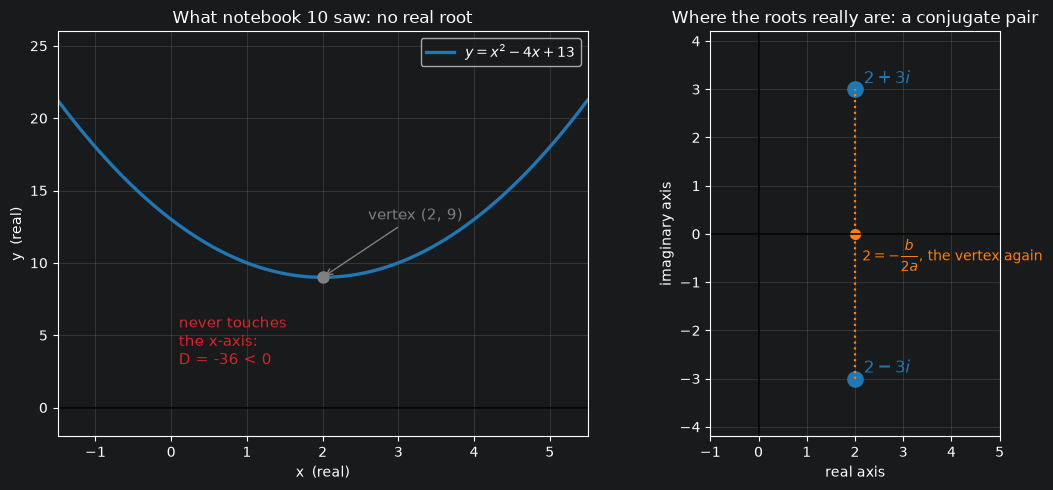

In [9]:
# --- Figure 8: no crossing on the left, two roots on the right ---

fig, (axL, axR) = plt.subplots(1, 2, figsize=(11.4, 5.0))

# ---------- left panel: the real graph of y = x^2 - 4x + 13 ----------
xs = np.linspace(-1.5, 5.5, 400)      # 400 evenly spaced x values
ys = xs**2 - 4*xs + 13                # the y value at each one
axL.plot(xs, ys, color=C_MAIN, linewidth=2.4, label=r"$y=x^{2}-4x+13$")
axL.axhline(0, color="black", linewidth=1.1)
axL.plot([2], [9], "o", color=C_GREY, markersize=8)          # the vertex (2, 9)
axL.annotate("vertex (2, 9)", xy=(2, 9), xytext=(2.6, 13),
             arrowprops=dict(arrowstyle="->", color=C_GREY), fontsize=11, color=C_GREY)
axL.text(0.1, 3.0, "never touches\nthe x-axis:\nD = -36 < 0",
         fontsize=11, color=C_BAD)
axL.set_xlim(-1.5, 5.5)
axL.set_ylim(-2, 26)
axL.grid(alpha=0.25)
axL.set_xlabel("x  (real)")
axL.set_ylabel("y  (real)")
axL.legend(loc="upper right", fontsize=10)
axL.set_title("What notebook 10 saw: no real root", fontsize=12)

# ---------- right panel: the same two roots, in the complex plane ----------
roots = [2 + 3j, 2 - 3j]              # the roots we computed by hand in Example 9
for r in roots:
    axR.plot(r.real, r.imag, "o", color=C_MAIN, markersize=11)
    axR.text(r.real + 0.18, r.imag + 0.12,
             r"$%d %s %di$" % (r.real, "+" if r.imag > 0 else "-", abs(r.imag)),
             fontsize=12, color=C_MAIN)
# the mirror line between the twins: the real axis
axR.plot([2, 2], [-3, 3], color=C_ALT, linestyle=":", linewidth=1.6)
axR.plot([2], [0], "o", color=C_ALT, markersize=7)
axR.text(2.15, -0.55, r"$2 = -\dfrac{b}{2a}$, the vertex again",
         fontsize=10, color=C_ALT)

axR.axhline(0, color="black", linewidth=1.1)
axR.axvline(0, color="black", linewidth=1.1)
axR.set_xlim(-1.0, 5.0)
axR.set_ylim(-4.2, 4.2)
axR.set_aspect("equal")
axR.grid(alpha=0.25)
axR.set_xlabel("real axis")
axR.set_ylabel("imaginary axis")
axR.set_title("Where the roots really are: a conjugate pair", fontsize=12)

plt.tight_layout()
plt.show()

Look at the right panel once more. The two roots sit **symmetrically above and below the real
axis**, and their common real part $2$ is exactly $-\frac{b}{2a}$ — the same number that gave
the vertex of the parabola in notebook 10 Theorem 10. The symmetry of the parabola and the
conjugate symmetry of the roots are the same fact, seen twice.

root = (1+0j)    its cube = (1+0j)
root = (-0.5+0.866j)    its cube = (1+0j)
root = (-0.5-0.866j)    its cube = (1-0j)


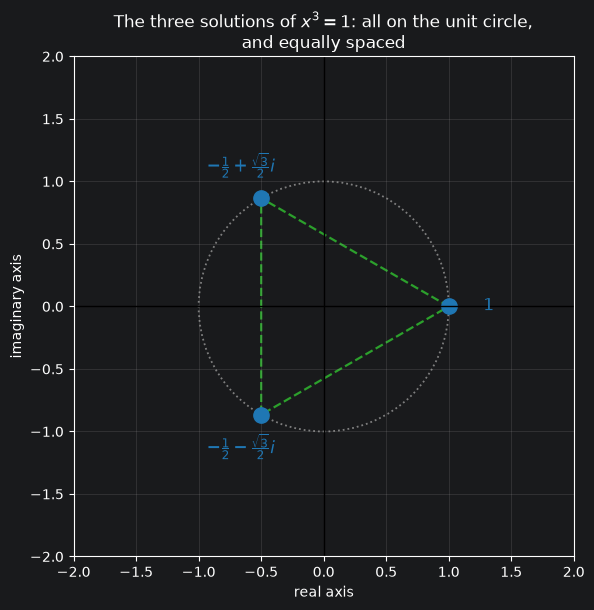

In [10]:
# --- Figure 9: the three cube roots of 1 (Example 13) sit on a circle ---

fig, ax = plt.subplots(figsize=(6.2, 6.2))

# the three roots we found by hand
roots = [1 + 0j,
         -0.5 + (np.sqrt(3) / 2) * 1j,
         -0.5 - (np.sqrt(3) / 2) * 1j]
labels = [r"$1$", r"$-\frac{1}{2}+\frac{\sqrt{3}}{2}i$", r"$-\frac{1}{2}-\frac{\sqrt{3}}{2}i$"]

ax.add_patch(Circle((0, 0), 1.0, fill=False, edgecolor=C_GREY,
                    linestyle=":", linewidth=1.3))

# join the three roots to show they form an equilateral triangle
tri = Polygon([(r.real, r.imag) for r in roots], closed=True,
              fill=False, edgecolor=C_GOOD, linewidth=1.6, linestyle="--")
ax.add_patch(tri)

for r, lab in zip(roots, labels):
    ax.plot(r.real, r.imag, "o", color=C_MAIN, markersize=11)
    ax.text(r.real * 1.32, r.imag * 1.30, lab, fontsize=12,
            ha="center", va="center", color=C_MAIN)
    # check by machine that each one really is a cube root of 1
    print("root =", np.round(r, 4), "   its cube =", np.round(r**3, 10))

ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlim(-2.0, 2.0)
ax.set_ylim(-2.0, 2.0)
ax.set_aspect("equal")
ax.grid(alpha=0.22)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.set_title(r"The three solutions of $x^{3}=1$: all on the unit circle,"
             "\nand equally spaced", fontsize=12)
plt.tight_layout()
plt.show()

---

## 6. Python demonstrations

### 6.1 Complex numbers are built into core Python

This is the first topic of the whole course where **you do not need a library**. Plain Python
already knows complex numbers. Two things to remember:

* Python writes the imaginary unit as `1j`, not `i` (electrical engineers had already taken
  the letter $i$ for electric current, and Python followed them). You must write the `1`:
  `1j`, `3j`, `-2j`.
* `z.real`, `z.imag`, `abs(z)` and `z.conjugate()` are exactly $\operatorname{Re}(z)$,
  $\operatorname{Im}(z)$, $|z|$ and $\bar z$ from Definitions 4, 5, 6.

In [11]:
# --- 6.1 the complex type of core Python: no library needed ---

z = 3 + 2j          # this is 3 + 2i  (Python spells the imaginary unit "1j")
w = 1 - 1j

print("z          =", z)
print("w          =", w)
print("z + w      =", z + w)          # Definition 1 / Theorem 4
print("z * w      =", z * w)          # (3+2i)(1-i) = 3-3i+2i-2i^2 = 5 - i
print("z / w      =", z / w)          # Theorem 6 does this for you
print()
print("z.real     =", z.real)         # Re(z)   - Definition 4
print("z.imag     =", z.imag)         # Im(z)   - a REAL number (Trap 3)
print("abs(z)     =", abs(z))         # |z|     - Definition 6, = sqrt(13)
print("z.conjugate() =", z.conjugate())   # z bar - Definition 5
print()
print("1j * 1j    =", 1j * 1j)        # Theorem 2: i^2 = -1  (Python prints (-1+0j))
print("type(z)    =", type(z))

# Theorem 5(4): z * conj(z) = |z|^2, and the answer is real
print()
print("z * z.conjugate() =", z * z.conjugate(), "   and |z|**2 =", abs(z)**2)

z          = (3+2j)
w          = (1-1j)
z + w      = (4+1j)
z * w      = (5-1j)
z / w      = (0.5+2.5j)

z.real     = 3.0
z.imag     = 2.0
abs(z)     = 3.605551275463989
z.conjugate() = (3-2j)

1j * 1j    = (-1+0j)
type(z)    = <class 'complex'>

z * z.conjugate() = (13+0j)    and |z|**2 = 12.999999999999998


Two things to notice in that output.

1. `1j * 1j` printed `(-1+0j)`, not `-1`. Python is telling you the **type** is still complex,
   with imaginary part zero. That is Trap 11, and it is not an error.
2. `abs(z)` gave a decimal. `abs` computes a square root, and $\sqrt{13}$ is irrational
   (nb 01!), so the computer can only store an approximation. If you want the exact answer,
   use SymPy, not the built-in type.

### 6.2 `math` refuses, `cmath` agrees

In [12]:
# --- 6.2 the two square-root functions, and why they disagree ---

import math            # math = real-number functions only
import cmath           # cmath = the same functions, but allowed to return complex numbers

try:
    print(math.sqrt(-1))
except ValueError as e:
    # math.sqrt refuses, and it is RIGHT to refuse: in R there is no such number
    print("math.sqrt(-1)  ->  ValueError:", e)

print("cmath.sqrt(-1) ->", cmath.sqrt(-1))     # gives 1j  (Definition 8)
print("cmath.sqrt(-9) ->", cmath.sqrt(-9))     # gives 3j
print()

# Trap 1, measured by machine instead of argued about:
wrong = cmath.sqrt(-4) * cmath.sqrt(-9)        # do it the honest way: each root first
right = cmath.sqrt((-4) * (-9))                # and the forbidden way: multiply inside
print("sqrt(-4)*sqrt(-9) =", wrong, "   <- the truth, = -6")
print("sqrt((-4)*(-9))   =", right, "   <- what the broken rule would give")
print("equal?", wrong == right)

math.sqrt(-1)  ->  ValueError: math domain error
cmath.sqrt(-1) -> 1j
cmath.sqrt(-9) -> 3j

sqrt(-4)*sqrt(-9) = (-6+0j)    <- the truth, = -6
sqrt((-4)*(-9))   = (6+0j)    <- what the broken rule would give
equal? False


### 6.3 Writing Theorem 11 as code

The best test of whether you understand a theorem is whether you can turn it into a program
that **branches exactly where the theorem branches**. Below, the code has three branches
because Theorem 11 has three cases — and it never calls a ready-made solver.

In [13]:
# --- 6.3 a quadratic solver that follows Theorem 11 line by line ---

def solve_quadratic(a, b, c):
    # Solve a x^2 + b x + c = 0 with REAL a, b, c. Returns (description, list of roots).
    if a == 0:
        return ("not quadratic (a = 0) - this is notebook 09 territory", None)

    D = b*b - 4*a*c                    # the discriminant, exactly as in notebook 10

    if D > 0:                          # case 1: two different real roots
        s = math.sqrt(D)               # a real square root is enough here
        return ("D > 0 : two real roots", [(-b + s) / (2*a), (-b - s) / (2*a)])

    if D == 0:                         # case 2: one double root
        return ("D = 0 : one double root", [-b / (2*a)])

    # case 3: D < 0. This is the branch notebook 10 could not finish.
    s = math.sqrt(-D)                  # -D is POSITIVE, so this is a real square root
    real_part = -b / (2*a)
    imag_part = s / (2*a)
    # build the two conjugate roots by hand, using complex(real, imaginary)
    return ("D < 0 : two roots, a conjugate pair",
            [complex(real_part, imag_part), complex(real_part, -imag_part)])

tests = [(1, -5, 6), (1, -4, 4), (1, -4, 13), (3, 2, 1), (2, 0, 8), (0, 2, 5)]

for a, b, c in tests:
    kind, roots = solve_quadratic(a, b, c)
    print(f"{a}x^2 + {b}x + {c} = 0")
    print("   ", kind)
    if roots is not None:
        print("    roots:", [complex(r) for r in roots])
        # CHECK every root by substituting it back into the equation (Definition 9)
        for r in roots:
            value = a*complex(r)**2 + b*complex(r) + c
            print(f"      check p({complex(r)}) = {value}")
    print()

1x^2 + -5x + 6 = 0
    D > 0 : two real roots
    roots: [(3+0j), (2+0j)]
      check p((3+0j)) = 0j
      check p((2+0j)) = 0j

1x^2 + -4x + 4 = 0
    D = 0 : one double root
    roots: [(2+0j)]
      check p((2+0j)) = 0j

1x^2 + -4x + 13 = 0
    D < 0 : two roots, a conjugate pair
    roots: [(2+3j), (2-3j)]
      check p((2+3j)) = 0j
      check p((2-3j)) = 0j

3x^2 + 2x + 1 = 0
    D < 0 : two roots, a conjugate pair
    roots: [(-0.3333333333333333+0.47140452079103173j), (-0.3333333333333333-0.47140452079103173j)]
      check p((-0.3333333333333333+0.47140452079103173j)) = 0j
      check p((-0.3333333333333333-0.47140452079103173j)) = 0j

2x^2 + 0x + 8 = 0
    D < 0 : two roots, a conjugate pair
    roots: [2j, -2j]
      check p(2j) = 0j
      check p(-2j) = 0j

0x^2 + 2x + 5 = 0
    not quadratic (a = 0) - this is notebook 09 territory



### 6.4 Checking Theorem 14 by machine

Theorem 14 gave a hand method for the square root of any complex number. Let us program it
exactly as the proof reads, and compare it with `cmath.sqrt` on random numbers. If the proof
is right, the two must agree up to the sign — and up to the small errors that decimals always
bring.

In [14]:
# --- 6.4 the square-root construction from the proof of Theorem 14 ---

def my_sqrt(w):
    # Square root of a complex number, built exactly as in the proof of Theorem 14.
    p, q = w.real, w.imag
    r = math.sqrt(p*p + q*q)                 # r = |w|,  equation (**)
    x = math.sqrt((r + p) / 2)               # x^2 = (r+p)/2   -> take the + root
    y = math.sqrt((r - p) / 2)               # y^2 = (r-p)/2   -> take the + root
    if q < 0:                                # the sign rule: x*y must have the sign of q
        y = -y
    return complex(x, y)

import random
random.seed(11)                              # same random numbers every run: reproducible

print(f"{'w':>26} {'my_sqrt(w)':>26} {'squared back':>26}   ok?")
for _ in range(6):
    w = complex(round(random.uniform(-9, 9), 2), round(random.uniform(-9, 9), 2))
    z = my_sqrt(w)
    back = z * z                             # square it again: we must land on w
    ok = abs(back - w) < 1e-9                # "close enough" - decimals are never exact
    print(f"{str(w):>26} {str(np.round(z, 6)):>26} {str(np.round(back, 6)):>26}   {ok}")

print()
print("Example 14 by hand said sqrt(3+4i) = 2+i.  My code says:", my_sqrt(3 + 4j))
print("Example 15 by hand said sqrt(-2i)  = 1-i.  My code says:", my_sqrt(-2j))
print("cmath.sqrt agrees:", cmath.sqrt(3 + 4j), cmath.sqrt(-2j))

                         w                 my_sqrt(w)               squared back   ok?
             (-0.86+1.08j)       (0.510186+1.058437j)              (-0.86+1.08j)   True
              (7.64-0.62j)       (2.766326-0.112062j)               (7.64-0.62j)   True
              (0.14+1.57j)       (0.926345+0.847417j)               (0.14+1.57j)   True
             (-5.68+0.21j)       (0.044049+2.383682j)              (-5.68+0.21j)   True
              (2.34+5.27j)       (2.013225+1.308845j)               (2.34+5.27j)   True
             (-7.31-3.54j)       (0.637201-2.777773j)              (-7.31-3.54j)   True

Example 14 by hand said sqrt(3+4i) = 2+i.  My code says: (2+1j)
Example 15 by hand said sqrt(-2i)  = 1-i.  My code says: (1-1j)
cmath.sqrt agrees: (2+1j) (1-1j)


### 6.5 Multiplication really is a rotation

Section 1.4 claimed that multiplying by $i$ turns the plane by $90^\circ$, and that
multiplying by $1+i$ turns it **and** stretches it by $|1+i|=\sqrt{2}$. Here is the proof by
picture: take a whole shape, multiply *every point of it* by the same complex number, and see
what happens to the shape.

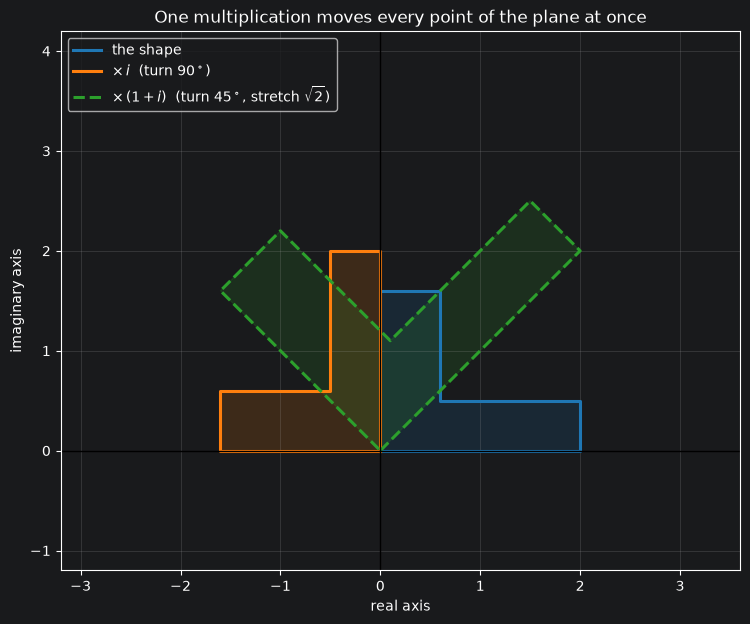

a side of the shape before: 2.0
the same side after * (1+i): 2.8284271247461903
ratio: 1.4142135623730951  and |1+i| = 1.4142135623730951


In [15]:
# --- Figure 10: multiply a whole shape by i, and by 1+i ---

# A little flag-shaped set of points, written as complex numbers.
shape = np.array([0+0j, 2+0j, 2+0.5j, 0.6+0.5j, 0.6+1.6j, 0+1.6j, 0+0j])

fig, ax = plt.subplots(figsize=(7.6, 7.0))

def draw(points, colour, label, style="-"):
    # .real and .imag work on a whole numpy array at once, giving x and y lists
    ax.plot(points.real, points.imag, style, color=colour, linewidth=2.2, label=label)
    ax.fill(points.real, points.imag, color=colour, alpha=0.16)

draw(shape,            C_MAIN, "the shape")
draw(shape * 1j,       C_ALT,  r"$\times\, i$  (turn $90^\circ$)")
draw(shape * (1 + 1j), C_GOOD, r"$\times\,(1+i)$  (turn $45^\circ$, stretch $\sqrt{2}$)",
     style="--")

ax.axhline(0, color="black", linewidth=1.0)
ax.axvline(0, color="black", linewidth=1.0)
ax.set_xlim(-3.2, 3.6)
ax.set_ylim(-1.2, 4.2)
ax.set_aspect("equal")        # ESSENTIAL here: a rotation must look like a rotation
ax.grid(alpha=0.25)
ax.legend(loc="upper left", fontsize=10)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.set_title("One multiplication moves every point of the plane at once", fontsize=12)
plt.tight_layout()
plt.show()

# the same statement in numbers: each length grew by exactly |1+i| = sqrt(2)
side_before = abs(shape[1] - shape[0])
side_after  = abs(shape[1] * (1 + 1j) - shape[0] * (1 + 1j))
print("a side of the shape before:", side_before)
print("the same side after * (1+i):", side_after)
print("ratio:", side_after / side_before, " and |1+i| =", abs(1 + 1j))

That last check is Theorem 7(3) at work: $|zw|=|z||w|$, so multiplying every point by $1+i$
multiplies every distance by $|1+i|=\sqrt{2}$. The shape keeps its form and changes its size —
this is exactly **similarity** from notebook 03, now produced by a single multiplication.

### 6.6 Conjugate pairs, seen

Theorem 13 says the non-real roots of a **real** polynomial come in mirror pairs. Let us take
a real polynomial of degree 7, ask NumPy for all its roots, and look.

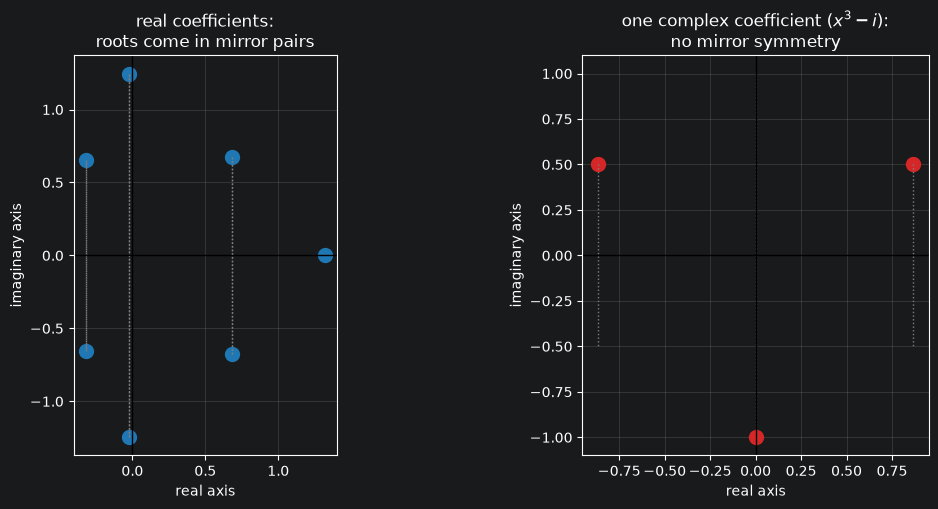

roots of the REAL polynomial (7 of them, Theorem 15):
    (-0.320783-0.653027j)
    (-0.320783+0.653027j)
    (-0.020336-1.24661j)
    (-0.020336+1.24661j)
    (0.682037-0.675862j)
    (0.682037+0.675862j)
    (1.318165+0j)

roots of x^3 - i  (Theorem 13 does NOT apply - the coefficient -i is not real):
    (-0.866025+0.5j)
    -1j
    (0.866025+0.5j)


In [16]:
# --- Figure 11: the roots of a real polynomial are symmetric about the real axis ---

# np.roots takes the coefficients from the highest power down to the constant.
# This polynomial is x^7 - 2x^6 + 3x^5 - 4x^4 + 3x^3 - 2x^2 + x - 1 : all coefficients REAL.
coeffs_real = [1, -2, 3, -4, 3, -2, 1, -1]
roots_real_poly = np.roots(coeffs_real)      # numpy finds all 7 roots, in C

# A second polynomial with a NON-real coefficient, for contrast: x^3 - i
coeffs_cplx = [1, 0, 0, -1j]
roots_cplx_poly = np.roots(coeffs_cplx)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.4, 5.2))

for ax, rts, title, colour in [
        (ax1, roots_real_poly, "real coefficients:\nroots come in mirror pairs", C_MAIN),
        (ax2, roots_cplx_poly, "one complex coefficient ($x^3-i$):\nno mirror symmetry", C_BAD)]:
    ax.plot(rts.real, rts.imag, "o", color=colour, markersize=10)
    # draw a thin line from each root to its mirror image, to make the pairing visible
    for r in rts:
        ax.plot([r.real, r.real], [r.imag, -r.imag], color=C_GREY,
                linestyle=":", linewidth=1.0)
    ax.axhline(0, color="black", linewidth=1.0)
    ax.axvline(0, color="black", linewidth=1.0)
    ax.set_aspect("equal")
    ax.grid(alpha=0.25)
    ax.set_xlabel("real axis")
    ax.set_ylabel("imaginary axis")
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()

print("roots of the REAL polynomial (7 of them, Theorem 15):")
for r in sorted(roots_real_poly, key=lambda r: (round(r.real, 6), r.imag)):
    print("   ", np.round(r, 6))
print()
print("roots of x^3 - i  (Theorem 13 does NOT apply - the coefficient -i is not real):")
for r in roots_cplx_poly:
    print("   ", np.round(r, 6))

### 6.7 Numerical-analysis lesson 9 — "is this root real?" is a question a computer cannot answer

Notebook 10 §6.6 showed you two roots that a computer insisted were one. Today the same
wound is deeper, and now we can describe it properly.

Take the equation
$$x^{2}-2x+(1+\varepsilon)=0 ,$$
where $\varepsilon$ is a tiny number. Its discriminant is $D = 4-4(1+\varepsilon) =
-4\varepsilon$, so by Theorem 11:

* if $\varepsilon<0$: two **real** roots, $1\pm\sqrt{-\varepsilon}$;
* if $\varepsilon=0$: one double **real** root, $x=1$;
* if $\varepsilon>0$: a **conjugate pair**, $1\pm i\sqrt{\varepsilon}$.

Now look at the sizes. If $\varepsilon = 10^{-16}$ — about the size of a rounding error in a
`float` — then the roots move away from $1$ by $\sqrt{10^{-16}} = 10^{-8}$. **A change of
$10^{-16}$ in a coefficient moves the roots by $10^{-8}$: one hundred million times more.**

The consequence is uncomfortable and important:

> Near a double root, the *type* of the answer (real or complex) depends on digits the
> computer does not have.

So when a program prints a root like `1.0000000037 + 0.0000000041j`, you cannot tell whether
the true root is real and the computer added a false imaginary part, or the root is genuinely
complex. **The mathematics is exact; the arithmetic is not.** This is why numerical software
usually asks you for a tolerance, and why "is it exactly zero?" is a question you should send
to SymPy, not to floats.

In [17]:
# --- 6.7 a coefficient change of 1e-16 moves the roots by 1e-8 ---

print("solving  x^2 - 2x + (1+eps) = 0   for tiny eps")
print(f"{'eps':>12} {'root 1':>34} {'root 2':>34}")
for eps in [-1e-8, -1e-12, -1e-16, 0.0, 1e-16, 1e-12, 1e-8]:
    # np.roots wants the coefficients, highest power first: 1, -2, 1+eps
    r = np.roots([1.0, -2.0, 1.0 + eps])
    print(f"{eps:>12.0e} {str(np.round(r[0], 10)):>34} {str(np.round(r[1], 10)):>34}")

print()
print("and the classic: the triple root of (x-1)^3 = x^3 - 3x^2 + 3x - 1")
r3 = np.roots([1.0, -3.0, 3.0, -1.0])
for r in r3:
    print("   ", r, "   |imaginary part| =", abs(r.imag))
print("   the true answer is x = 1 three times: every imaginary part above is pure error")

solving  x^2 - 2x + (1+eps) = 0   for tiny eps
         eps                             root 1                             root 2
      -1e-08                             1.0001                             0.9999
      -1e-12                           1.000001                           0.999999
      -1e-16                       1.0000000149                       0.9999999851
       0e+00                                1.0                                1.0
       1e-16                                1.0                                1.0
       1e-12                         (1+1e-06j)                         (1-1e-06j)
       1e-08                        (1+0.0001j)                        (1-0.0001j)

and the classic: the triple root of (x-1)^3 = x^3 - 3x^2 + 3x - 1
    (1.0000065704250627+0j)    |imaginary part| = 0.0
    (0.9999967147874662+5.6901538690326425e-06j)    |imaginary part| = 5.6901538690326425e-06
    (0.9999967147874662-5.6901538690326425e-06j)    |imaginary part| = 5.6

**Read that table carefully — the last surprise is in it.**

For $\varepsilon = +10^{-16}$, Theorem 11 says the roots must be $1\pm 10^{-8}i$, a conjugate
pair. The computer printed two **real** roots equal to $1$. Why?

Because the computer never saw $\varepsilon$ at all. In `float` arithmetic,
`1.0 + 1e-16 == 1.0` is **True**: the tiny number is thrown away when it is added to $1$,
before the solver even starts. The coefficient the program actually solved with was $1$, not
$1+10^{-16}$.

And for $\varepsilon=-10^{-16}$ the same throwing-away happened, yet the printed roots differ
from $1$ by about $1.5\times10^{-8}$ — that is rounding noise inside the solver, of exactly
the same size as a genuine answer would have been.

So the two failures point in opposite directions: sometimes the machine **hides** a real
effect, sometimes it **invents** one. That is the whole lesson, and it is why the last line of
defence is always the theorem, never the printout.

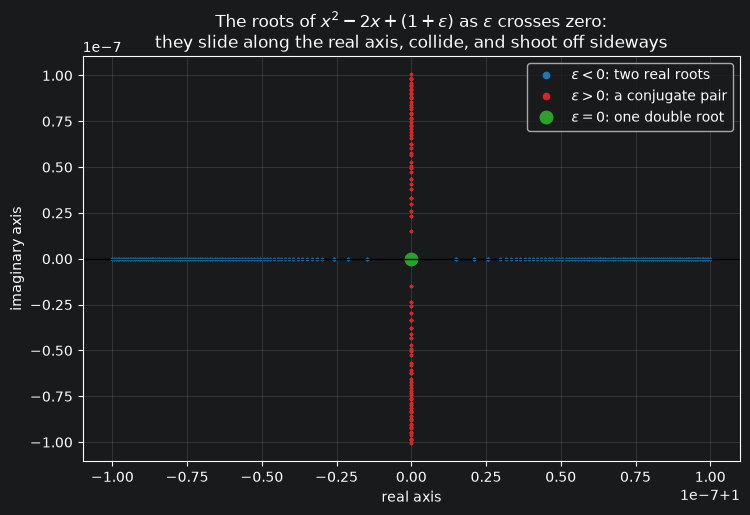

In [18]:
# --- Figure 12: the roots leave the real axis exactly when eps changes sign ---

fig, ax = plt.subplots(figsize=(7.6, 5.4))

# a sweep of eps values, from negative (real roots) to positive (complex roots)
eps_values = np.linspace(-1e-14, 1e-14, 401)

for eps in eps_values:
    r = np.roots([1.0, -2.0, 1.0 + eps])          # solve for this eps
    colour = C_BAD if eps > 0 else C_MAIN         # colour by which case we are in
    ax.plot(r.real, r.imag, ".", color=colour, markersize=3)

ax.plot([], [], ".", color=C_MAIN, markersize=9, label=r"$\varepsilon<0$: two real roots")
ax.plot([], [], ".", color=C_BAD,  markersize=9, label=r"$\varepsilon>0$: a conjugate pair")
ax.plot([1], [0], "o", color=C_GOOD, markersize=9,
        label=r"$\varepsilon=0$: one double root")

ax.axhline(0, color="black", linewidth=1.0)
ax.grid(alpha=0.25)
ax.set_xlabel("real axis")
ax.set_ylabel("imaginary axis")
ax.legend(loc="upper right", fontsize=10)
ax.set_title("The roots of $x^2-2x+(1+\\varepsilon)$ as $\\varepsilon$ crosses zero:\n"
             "they slide along the real axis, collide, and shoot off sideways",
             fontsize=12)
plt.tight_layout()
plt.show()

The picture is a **cross**. Coming from the left ($\varepsilon<0$) the two real roots slide
towards each other along the real axis, meet at $x=1$, and then leave the axis vertically as a
conjugate pair. Notice that they leave *perpendicular* to the way they came in. That right
angle is not decoration — it is $\sqrt{\phantom{x}}$ of a negative number, which is
multiplication by $i$, which is a quarter turn (§1.4). The same idea, one last time.

---

## 7. Exercises — all 20 are for you

Rules, as always:

* **Answer by hand first.** The code cell is for *checking*, not for solving.
* Write the solution set as a **set**, and say **where** you are solving: in $\mathbb{R}$ or
  in $\mathbb{C}$ (Trap 9).
* Keep answers **exact** ($\frac{\sqrt{3}}{2}$, not $0.866$) and in **standard form** $a+bi$.
* On the proof exercises, name every theorem you use. If you get stuck, write down **exactly
  where** you got stuck and what you tried — that sentence is worth more to me than a right
  answer.

### Exercise 1 — arithmetic, by hand

Write each answer in standard form $a+bi$.

(a) $(4-3i)+(-2+8i)$
(b) $(4-3i)-(-2+8i)$
(c) $(2-5i)(3+i)$
(d) $(1-i)^{2}$
(e) $(3+2i)(3-2i)$
(f) $-4i(2-7i)$

In [ ]:
# your work for Exercise 1

### Exercise 2 — powers of $i$

Use Theorem 8; do not multiply many times.

(a) $i^{17}$  (b) $i^{40}$  (c) $i^{2027}$  (d) $i^{-6}$
(e) $i+i^{2}+i^{3}+i^{4}$
(f) $i+i^{2}+i^{3}+\dots+i^{100}$ — and explain the pattern in one sentence.

In [ ]:
# your work for Exercise 2

### Exercise 3 — conjugate and modulus

For $z = -5+12i$ and $w = 4-3i$, compute by hand:

(a) $\bar z$, $|z|$
(b) $\bar w$, $|w|$
(c) $z\bar z$ — and say which theorem predicted the answer before you multiplied
(d) $|zw|$, computed **twice**: once by multiplying first, once by Theorem 7(3)
(e) $|z+w|$ and $|z|+|w|$ — which is bigger, and which theorem says it must be?

In [ ]:
# your work for Exercise 3

### Exercise 4 — division

Write in standard form.

(a) $\dfrac{1}{i}$  (b) $\dfrac{3}{2+i}$  (c) $\dfrac{5-2i}{3+4i}$  (d) $\dfrac{1+i}{1-i}$

For (d), also say what the answer means as a **rotation** (compare Figure 10).

In [ ]:
# your work for Exercise 4

### Exercise 5 — the radical trap

(a) Compute $\sqrt{-4}\cdot\sqrt{-25}$ correctly.
(b) A student writes $\sqrt{-4}\cdot\sqrt{-25} = \sqrt{100} = 10$. Which theorem did they use,
what does that theorem **require**, and which requirement failed?
(c) Is $\sqrt{-4}\cdot\sqrt{25}=\sqrt{-100}$ true or false? Justify — this one is different
from (a), and the difference is the whole point.

In [ ]:
# your work for Exercise 5

### Exercise 6 — simple equations, in $\mathbb{R}$ and in $\mathbb{C}$

For each equation give **both** answers: the solution set in $\mathbb{R}$, and the solution
set in $\mathbb{C}$.

(a) $x^{2}=-16$  (b) $x^{2}+7=0$  (c) $2x^{2}+50=0$  (d) $(x-3)^{2}=-4$  (e) $x^{2}=0$

In [ ]:
# your work for Exercise 6

### Exercise 7 — real quadratics with $D<0$

Solve in $\mathbb{C}$, exactly, in standard form. State $D$ **before** you solve.

(a) $x^{2}-2x+5=0$
(b) $x^{2}+4x+13=0$
(c) $2x^{2}-2x+1=0$
(d) $5x^{2}+2x+1=0$

For one of them, check your answer by substituting it back.

In [ ]:
# your work for Exercise 7

### Exercise 8 — read the discriminant, do not solve

Fill in this table without finding a single root.

| Equation | $D$ | number of real roots | number of complex roots | are the roots conjugates? |
| --- | --- | --- | --- | --- |
| $x^{2}-6x+9=0$ | | | | |
| $x^{2}-6x+10=0$ | | | | |
| $x^{2}-6x+5=0$ | | | | |
| $3x^{2}+x+2=0$ | | | | |

Then answer: **can the last column ever say "no" for these four?** Why?

In [ ]:
# your work for Exercise 8

### Exercise 9 — build the equation from a root

(a) Find a quadratic equation with **real** coefficients having $3-i$ as a root.
(b) Explain why the answer to (a) is forced — which theorem removes your freedom?
(c) Find a quadratic equation with **complex** coefficients having $3-i$ as a root and $5$ as
the other root. Are its roots a conjugate pair? Is that a contradiction of Theorem 13?

In [ ]:
# your work for Exercise 9

### Exercise 10 — factor completely over $\mathbb{C}$

(a) $x^{2}+25$
(b) $x^{4}-16$
(c) $x^{2}-2x+2$
(d) $x^{4}+64$ — *hint:* copy the trick of Example 12(c): add and subtract the right multiple
of $x^{2}$ to make a perfect square, then use the difference of squares.

For each one, count the factors and check the count against Theorem 15.

In [ ]:
# your work for Exercise 10

### Exercise 11 — Vieta over $\mathbb{C}$

The equation $x^{2}+bx+c=0$ has real coefficients and one root $2-5i$.

(a) Write down the other root immediately, with a reason.
(b) Find $b$ and $c$ using Theorem 12 — **without** using the quadratic formula.
(c) A different equation $x^{2}+bx+c=0$ has roots $1+i$ and $2+3i$. Find $b$ and $c$. Can
$b$ and $c$ be real here? Explain, using Theorem 13.

In [ ]:
# your work for Exercise 11

### Exercise 12 — square roots of complex numbers

Use the method of Theorem 14 (show the numbers $r$, $x^{2}$, $y^{2}$ and the sign rule).

(a) $\sqrt{-5+12i}$
(b) $\sqrt{8-6i}$
(c) $\sqrt{2i}$
(d) Check each answer by squaring it back.

In [ ]:
# your work for Exercise 12

### Exercise 13 — a quadratic with complex coefficients

Solve $z^{2}-(2+2i)z+(1+2i)=0$ in $\mathbb{C}$, by hand.

Show $D$, show your square root of $D$ (Theorem 14), then the two roots. Finally check your
answers with Vieta (Theorem 12).

In [ ]:
# your work for Exercise 13

### Exercise 14 — find the mistakes

Each written solution below is wrong. Find **every** error, name the trap or the theorem, and
give the correct answer.

**Solution A.**
> Solve $x^{2}+16=0$.
> $x^{2}=-16$, so $x=\sqrt{-16}=4i$. Therefore $S=\{4i\}$.

**Solution B.**
> Simplify $\dfrac{2}{3i}$.
> $\dfrac{2}{3i} = \dfrac{2}{3}\cdot\dfrac{1}{i} = \dfrac{2}{3}i$.

**Solution C.**
> Solve $x^{2}-6x+13=0$.
> $D = 36-52 = -16$, so $x = \dfrac{6\pm\sqrt{-16}}{2} = \dfrac{6\pm4i}{2} = 6\pm2i$.

**Solution D.**
> $(2+3i)$ is bigger than $(1+i)$, because $2>1$ and $3>1$.

In [ ]:
# your work for Exercise 14

### Exercise 15 — Python: build the complex numbers yourself

Using **core Python only** (no `complex`, no libraries), write a class `Cx` that stores a pair
of real numbers `a`, `b` and implements:

* `__add__` and `__mul__` following Definition 1 exactly,
* `conj()` and `modulus()`,
* `__repr__` printing standard form, e.g. `3 - 2i`.

Then test it: check `Cx(0,1) * Cx(0,1)` equals $-1$ (Theorem 2), and check on three random
pairs that `(z*w).modulus()` equals `z.modulus() * w.modulus()` (Theorem 7(3)).

*This exercise is the whole notebook in code: if your class works, you have built
$\mathbb{C}$.*

In [ ]:
# your work for Exercise 15

### Exercise 16 — Python: draw a spiral

Take $z = 0.9+0.4i$ and plot the points $z^{0}, z^{1}, z^{2},\dots,z^{20}$ in the complex
plane with matplotlib, joined by a line.

(a) Describe the shape in one sentence.
(b) Compute $|z|$. Predict, **before running**, whether the points spiral inwards or outwards,
and say which theorem gives you the answer.
(c) Repeat with $z = 1.1+0.4i$ and with a $z$ you choose so that $|z|=1$ exactly. What happens
in each case?

In [ ]:
# your work for Exercise 16

### Exercise 17 — Python: the numerical lesson, on your own

(a) Solve $x^{2}-2x+1=0$ with `np.roots`. Are the printed roots exactly $1$?
(b) Now solve $x^{2}-2x+(1+\varepsilon)=0$ for $\varepsilon = 10^{-10}, 10^{-14}, 10^{-18}$
and print the imaginary parts.
(c) For $\varepsilon = 10^{-18}$, what does the computer say, and what does **Theorem 11**
say? Which one is right, and why do they differ?
(d) In two sentences: why can you not decide "is this root real?" by looking at the printed
imaginary part?

In [ ]:
# your work for Exercise 17

### Exercise 18 — proof: conjugate rules

Prove, for all $z,w\in\mathbb{C}$, writing $z=a+bi$ and $w=c+di$:

(a) $\overline{z-w} = \bar z-\bar w$;
(b) $\overline{\left(\dfrac{z}{w}\right)} = \dfrac{\bar z}{\bar w}$ for $w\ne0$
 — *hint:* start from $\dfrac{z}{w}\cdot w = z$ and use Theorem 5(2);
(c) $\overline{z^{n}} = \bar z^{\,n}$ for every integer $n\ge1$, **by induction** (the
technique of notebook 02).

In [ ]:
# your work for Exercise 18

### Exercise 19 — proof: size

(a) Prove $|z^{n}| = |z|^{n}$ for every integer $n\ge1$, by induction from Theorem 7(3).
(b) Prove $\left|\dfrac{z}{w}\right| = \dfrac{|z|}{|w|}$ for $w\ne0$.
(c) Prove the **reverse triangle inequality**: $\big||z|-|w|\big| \le |z-w|$.
 *Hint:* apply the triangle inequality to $z = (z-w)+w$ to get one half, then swap $z$ and $w$
 for the other half.

In [ ]:
# your work for Exercise 19

### Exercise 20 — the hard one (three parts)

**(a)** Prove the conjugate root theorem (Theorem 13) for the special case of a **cubic**
$p(x)=a_{3}x^{3}+a_{2}x^{2}+a_{1}x+a_{0}$ with real coefficients, writing out every use of
Theorem 5. Then, assuming Theorem 15 (the Fundamental Theorem of Algebra), prove that this
cubic has **at least one real root**.

**(b)** Prove that there is no way to define $<$ on $\mathbb{C}$ obeying the order axioms
(Theorem 9). Write the proof yourself, in your own words, without looking at §3.5 — then
compare.

**(c)** Let $z\in\mathbb{C}$, $z\ne0$. Prove:

> if $z+\dfrac1z$ is a **real** number, then either $z$ is real, or $|z|=1$.

*Hint:* "$u$ is real" means $u=\bar u$ (Theorem 5(6)). Write that out for $u = z+\frac1z$,
move everything to one side, and try to factor. Something of the form
$(z-\bar z)\cdot(\text{something})=0$ should appear, and then the zero-product property
finishes the job.

**If you get stuck on (c), stop and write me the exact line where you stopped, and what you
tried.** I have asked for that five times now and never received it. It is the single most
useful thing you can send me, because it tells me what to teach next.

In [ ]:
# your work for Exercise 20

---

## 8. Say it back to me (no writing, just talking)

Answer these out loud, in your own words. If an answer takes more than four sentences, you
have not understood it yet.

1. I say: *"$i$ is a number whose square is $-1$ — but notebook 01 proved every square is
   $\ge 0$, so mathematics is broken."* Show me exactly where that sentence is wrong.

2. Why is the multiplication rule $(a,b)(c,d)=(ac-bd,\ ad+bc)$ and not the "obvious"
   $(ac,\ bd)$? Give the reason in terms of what would **break**.

3. $\sqrt{-4}\cdot\sqrt{-9}$. Give the answer, and then explain the mistake most people make
   — naming the theorem and the hypothesis that fails.

4. Is $i$ bigger or smaller than $1$? Careful: this is a trap. Say what is really going on,
   and name the theorem.

5. Notebook 10 said $x^{2}+1=0$ has no solution. Today I say it has two. Was notebook 10
   wrong? Answer in one sentence.

6. A real quadratic has one root $3+7i$. Tell me the other root **instantly**, and tell me why
   you are allowed to.

7. The hardest one: I run a program, and it prints the roots of a real quadratic as
   $1.0000000037 \pm 0.0000000041\,i$. Are the true roots real or complex? What is the honest
   answer, and why?

---

## 9. Running this notebook with `uv`

This notebook needs nothing new. Everything it uses — `numpy`, `sympy`, `matplotlib` — is
already in `pyproject.toml`, and `math`, `cmath` and `random` come with Python itself.

```bash
uv sync              # install the dependencies listed in pyproject.toml
uv run jupyter lab   # start Jupyter and open notebooks/11-complex-numbers.ipynb
```

Then run the notebook from the top: **Kernel -> Restart Kernel and Run All Cells**. Every cell
must run with no error. If one fails, tell me which one.

If a future notebook ever needs a package that is not installed, add it first with, for
example, `uv add pandas` — never write an `import` for a package that is not in
`pyproject.toml`.

### Where we go next

Next in `math-topic.md` is *Equations and Inequalities* § 4: **Radical Equations; Equations
Quadratic in Form; Factorable Equations** (`notebooks/12-radical-and-quadratic-form-equations.ipynb`).

That topic leans on two things you now own:

* the **domain-first habit** from notebook 09, because squaring both sides of an equation can
  create fake solutions — and checking will stop being optional;
* today's lesson that **the set you solve in changes the answer**. A radical equation solved
  in $\mathbb{R}$ and in $\mathbb{C}$ can have different solution sets, and you will have to
  say which one you mean.

**Before that, please send me exercise answers.** Notebook 10 Exercise 14 (find the mistakes)
takes ten minutes and needs no calculation at all. Eleven notebooks of homework are now
outstanding, and I am still guessing about what you find hard.